In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler, minmax_scale
from xgboost import XGBClassifier

from main_event import prepare_event_data, prepare_json_event_data
from preprocessing import PreProcessing
from utils import (
    add_shot_prediction_features,
    calculate_velocity_acceleration,
    calculate_velocity_direction,
    calculate_velocity_acceleration_direction,
    calculate_player_ball_distances,
    get_n_smallest_indices_sorted,
    get_frame_data,
    process_event_data, 
    plot_confusion_matrix, 
    plot_accuracy_history
)

ModuleNotFoundError: No module named 'main_event'

## You'll see the data goes from 0 to 1 on each axis. The coordiante (0,0) is the top left, (1,1) is the bottom right, and (0.5,0.5) is the kick off point.

In [ ]:
game_1_pre = PreProcessing()
game_1_data = game_1_pre.load_and_process_data(
    data_home="data/Sample_Game_1/Sample_Game_1_RawTrackingData_Home_Team.csv", 
    data_away="data/Sample_Game_1/Sample_Game_1_RawTrackingData_Away_Team.csv", 
    add_ball_data=True, 
    remove_ball_nan=False
)

In [ ]:
game_2_pre = PreProcessing()
game_2_data = game_2_pre.load_and_process_data(
    data_home="data/Sample_Game_2/Sample_Game_2_RawTrackingData_Home_Team.csv", 
    data_away="data/Sample_Game_2/Sample_Game_2_RawTrackingData_Away_Team.csv", 
    add_ball_data=True, 
    remove_ball_nan=False
)

In [ ]:
game_3_pre = PreProcessing()
game_3_data = game_3_pre.load_and_process_json_data(
    data_home_away="data/Sample_Game_3/Sample_Game_3_tracking.txt", 
    add_ball_data=True, 
    remove_ball_nan=False
)

In [ ]:
# game_1_data.iloc[:, 25:-2] = -1 * game_1_data.iloc[:, 25:-2]
game_1_data

In [ ]:
# game_2_data.iloc[:, 25:-2] = -1 * game_2_data.iloc[:, 25:-2]
game_2_data

In [ ]:
game_3_data

## Tracking for individual Players Visualization

In [ ]:
sides = ["Home"] * 11 + ["Away"] * 11
players = list(range(1, 12)) + list(range(15, 26))
game_2_pre.player_visualization(game_1_data.loc[7753:7754], players=players, sides=sides, plot_ball=True)
# game_2_pre.player_visualization(game_2_data.iloc[2:3], players=[1,2,3,4,5,6,7,8,9,10,11], sides=["Home"]*11, plot_ball=False)

In [ ]:
# player_tracking(period_1_data)
# player_tracking(period_1_data_home, [2])
# player_tracking(period_1_data_home, [5])
# player_tracking(period_1_data_home, [8])

# Getting the labels

In [ ]:
game_1_event = prepare_event_data("data/Sample_Game_1/Sample_Game_1_RawEventsData.csv", game_1_data)
game_2_event = prepare_event_data("data/Sample_Game_2/Sample_Game_2_RawEventsData.csv", game_2_data)
game_3_event = prepare_json_event_data("data/Sample_Game_3/Sample_Game_3_events.json", game_3_data)

In [ ]:
game_1_event

In [ ]:
game_2_event

In [ ]:
game_3_event

In [ ]:
common_indices = game_1_event.index.intersection(game_1_event.index)
X_1 = game_1_data.loc[common_indices]
X_1 = X_1.iloc[:, 3:]
y_1 = game_1_event.loc[common_indices]

assert X_1.shape[0] == y_1.shape[0]

In [ ]:
common_indices = game_2_event.index.intersection(game_2_event.index)
X_2 = game_2_data.loc[common_indices]
X_2 = X_2.iloc[:, 3:]
y_2 = game_2_event.loc[common_indices]

assert X_2.shape[0] == y_2.shape[0]

In [ ]:
common_indices = game_3_event.index.intersection(game_3_event.index)
X_3 = game_3_data.loc[common_indices]
X_3 = X_3.iloc[:, 2:]
y_3 = game_3_event.loc[common_indices]

assert X_3.shape[0] == y_3.shape[0]

In [ ]:
X_1

# Smote oversampling

In [ ]:
smote = SMOTE(random_state=42)
X_1_oversampled, y_1_oversampled = smote.fit_resample(X_1, y_1)

X_1_oversampled.index = range(1, len(X_1_oversampled) + 1)
y_1_oversampled.index = range(1, len(y_1_oversampled) + 1)

X_1_oversampled.insert(0, "Frame", X_1_oversampled.index)

In [ ]:
smote = SMOTE(random_state=42)
X_2_oversampled, y_2_oversampled = smote.fit_resample(X_2, y_2)

X_2_oversampled.index = range(1, len(X_2_oversampled) + 1)
y_2_oversampled.index = range(1, len(y_2_oversampled) + 1)

X_2_oversampled.insert(0, "Frame", X_2_oversampled.index)

In [ ]:
smote = SMOTE(random_state=42)
X_3_oversampled, y_3_oversampled = smote.fit_resample(X_3, y_3)

X_3_oversampled.index = range(1, len(X_3_oversampled) + 1)
y_3_oversampled.index = range(1, len(y_3_oversampled) + 1)

X_3_oversampled.insert(0, "Frame", X_3_oversampled.index)

In [ ]:
X_3_oversampled

# Adding extra features to dataset

In [ ]:
vel_acc_game_1_data = calculate_velocity_acceleration_direction(X_1_oversampled)
vel_acc_game_2_data = calculate_velocity_acceleration_direction(X_2_oversampled)
vel_acc_game_3_data = calculate_velocity_acceleration_direction(X_3_oversampled)

In [ ]:
vel_acc_game_1_data

In [ ]:
game_1_ply_tra = vel_acc_game_1_data.iloc[:, 1:]
game_2_ply_tra = vel_acc_game_2_data.iloc[:, 1:]
game_3_ply_tra = vel_acc_game_3_data.iloc[:, 1:]

In [ ]:
game_2_ply_tra

In [ ]:
# game_1_player_data = get_frame_data(game_1_ply_tra, columns=game_1_ply_tra.columns[0:46:2], feature="direction").fillna(0)
# game_2_player_data = get_frame_data(game_2_ply_tra, columns=game_2_ply_tra.columns[0:46:2], feature="direction").fillna(0)
# game_3_player_data = get_frame_data(game_3_ply_tra, columns=game_3_ply_tra.columns[0:46:2], feature="direction").fillna(0)

In [ ]:
game_1_player_data = game_1_ply_tra.fillna(0).copy()
game_2_player_data = game_2_ply_tra.fillna(0).copy()
game_3_player_data = game_3_ply_tra.fillna(0).copy()

In [ ]:
game_1_player_data = add_shot_prediction_features(game_1_player_data)
game_2_player_data = add_shot_prediction_features(game_2_player_data)
game_3_player_data = add_shot_prediction_features(game_3_player_data)

X_1_oversampled = game_1_player_data.iloc[:, :]
X_2_oversampled = game_2_player_data.iloc[:, :]
X_3_oversampled = game_3_player_data.iloc[:, :]

In [ ]:
game_1_player_data

### Adding which team has the ball using distance metrics

In [ ]:
game_1_players, game_1_ball, game_1_vel_acc = vel_acc_game_1_data.loc[X_1_oversampled.index, "Home-Player11-x":"Away-Player24-y"], vel_acc_game_1_data.loc[X_1_oversampled.index, "Ball-x":"Ball-y"], vel_acc_game_1_data.loc[X_1_oversampled.index, "P_11_velocity":]
game_2_players, game_2_ball, game_2_vel_acc = vel_acc_game_2_data.loc[X_2_oversampled.index, "Home-Player11-x":"Away-Player24-y"], vel_acc_game_2_data.loc[X_2_oversampled.index, "Ball-x":"Ball-y"], vel_acc_game_2_data.loc[X_2_oversampled.index, "P_11_velocity":]
game_3_players, game_3_ball, game_3_vel_acc = vel_acc_game_3_data.loc[X_3_oversampled.index, "Home-Player11-x":"Away-Player24-y"], vel_acc_game_3_data.loc[X_3_oversampled.index, "Ball-x":"Ball-y"], vel_acc_game_3_data.loc[X_3_oversampled.index, "P_11_velocity":]

In [ ]:
game_1_result = calculate_player_ball_distances(
    game_data=X_1_oversampled,
    player_data=game_1_players,
    ball_data=game_1_ball
)
game_1_result

In [ ]:
game_2_result = calculate_player_ball_distances(
    game_data=X_2_oversampled,
    player_data=game_2_players,
    ball_data=game_2_ball
)
game_2_result

In [ ]:
game_3_result = calculate_player_ball_distances(
    game_data=X_3_oversampled,
    player_data=game_3_players,
    ball_data=game_3_ball
)
game_3_result

In [ ]:
game_1_closest_to_ball = get_n_smallest_indices_sorted(game_1_result.iloc[:, 1:], 1)
game_2_closest_to_ball = get_n_smallest_indices_sorted(game_2_result.iloc[:, 1:], 1)
game_3_closest_to_ball = get_n_smallest_indices_sorted(game_3_result.iloc[:, 1:], 1)
game_3_closest_to_ball

In [ ]:
def add_ball_with(closest_to_ball: pd.DataFrame):
    # Assume the column of interest is the first column.
    col = closest_to_ball.iloc[:, 0].str.lower()
    
    # Use numpy.where to vectorize the assignment.
    team = np.where(col.str.startswith("home"), 0, 
                    np.where(col.str.startswith("away"), 1, np.nan))
    return team

In [2]:
X_1_oversampled["Team"] = add_ball_with(game_1_closest_to_ball)
X_2_oversampled["Team"] = add_ball_with(game_2_closest_to_ball)
X_3_oversampled["Team"] = add_ball_with(game_3_closest_to_ball)

NameError: name 'add_ball_with' is not defined

In [39]:
X_3_oversampled

,Home-Player11-x,Home-Player11-y,Home-Player1-x,Home-Player1-y,Home-Player2-x,Home-Player2-y,Home-Player3-x,Home-Player3-y,Home-Player4-x,Home-Player4-y,...,P_24_velocity,P_24_acceleration,P_24_direction_sin,P_24_direction_cos,Ball_velocity,Ball_acceleration,Ball_direction_sin,Ball_direction_cos,Ball_shot_probability,Team
1,0.848960,0.508820,0.632850,0.183200,0.737580,0.395660,0.717920,0.664650,0.554290,0.911390,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,0.849390,0.508640,0.632670,0.182790,0.737730,0.396060,0.717910,0.665120,0.554300,0.911920,...,-0.833765,0.000000,0.472221,0.881480,-0.828965,0.000000,0.726065,0.687626,0.000000,0.0
3,0.849870,0.508340,0.632480,0.182550,0.737890,0.396540,0.717910,0.665550,0.554300,0.912410,...,-0.833794,-0.000037,0.413005,0.910729,-0.820566,0.009250,0.737850,0.674965,0.000000,0.0
4,0.850340,0.508160,0.632300,0.182210,0.738060,0.396920,0.717910,0.666000,0.554300,0.912920,...,-0.833686,0.000116,0.409939,0.912113,-0.820590,-0.000029,0.738894,0.673821,0.000000,0.0
5,0.850800,0.507990,0.632110,0.181880,0.738200,0.397350,0.717870,0.666520,0.554280,0.913420,...,-0.833577,0.000116,0.407059,0.913402,-0.820592,-0.000006,0.736893,0.676010,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171580,0.987810,0.512021,0.930701,0.269376,0.899821,0.484320,0.905991,0.525779,0.792284,0.608525,...,-0.570972,-0.008070,0.836192,-0.548437,-0.249017,0.050006,0.907659,-0.419708,0.000000,0.0
171581,0.057604,0.480204,0.564431,0.709759,0.588340,0.840198,0.519718,0.606550,0.714409,0.357492,...,-0.641710,-0.077944,-0.766444,0.642311,-0.232428,0.018275,-0.993352,0.115116,0.000000,0.0
171582,0.939889,0.502062,0.292478,0.437035,0.056466,0.547168,0.050005,0.468916,0.379811,0.633940,...,2.295913,3.236723,0.140471,-0.990085,2.380285,2.878732,0.062248,-0.998061,1.000000,1.0
171583,0.099012,0.507382,0.900873,0.666052,0.480546,0.712038,0.455964,0.524847,0.616990,0.352902,...,0.600295,-1.868266,0.203877,0.978997,2.429180,0.053870,0.112452,0.993657,0.975489,1.0


In [39]:
# away_cols = X_1.columns.str.startswith("Away")
# X_1.loc[:, away_cols] = X_1.loc[:, away_cols] * -1

# away_cols = X_2.columns.str.startswith("Away")
# X_2.loc[:, away_cols] = X_2.loc[:, away_cols] * -1

# away_cols = X_3.columns.str.startswith("Away")
# X_3.loc[:, away_cols] = X_3.loc[:, away_cols] * -1

In [40]:
np.unique(y_1_oversampled, return_counts=True)

(array(['BALL LOST', 'BALL OUT', 'PASS', 'SHOT'], dtype=object),
 array([28147, 28147, 28147, 28147], dtype=int64))

In [41]:
np.unique(y_2_oversampled, return_counts=True)

(array(['BALL LOST', 'BALL OUT', 'PASS', 'SHOT'], dtype=object),
 array([32338, 32338, 32338, 32338], dtype=int64))

In [42]:
np.unique(y_3_oversampled, return_counts=True)

(array(['BALL LOST', 'BALL OUT', 'PASS', 'SHOT'], dtype=object),
 array([42896, 42896, 42896, 42896], dtype=int64))

In [43]:
scaler = MinMaxScaler()
X_1_scaled = X_1_oversampled.values#pd.concat([X_1.iloc[:, :46], X_1.iloc[:, -3:]], axis=1).values#scaler.fit_transform(X_1)
X_2_scaled = X_2_oversampled.values#pd.concat([X_2.iloc[:, :46], X_2.iloc[:, -3:]], axis=1).values#scaler.transform(X_2)
X_3_scaled = X_3_oversampled.values#pd.concat([X_3.iloc[:, :46], X_3.iloc[:, -3:]], axis=1).values#scaler.transform(X_3)

# X_1_scaled = minmax_scale(X_1, axis=0)
# X_2_scaled = minmax_scale(X_2, axis=0)
# X_3_scaled = minmax_scale(X_3, axis=0)

label_encoder = LabelEncoder()
y_1_encoded = label_encoder.fit_transform(y_1_oversampled)
y_2_encoded = label_encoder.transform(y_2_oversampled)
y_3_encoded = label_encoder.transform(y_3_oversampled)

C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
C:\Users\noill\OneDrive\Desktop\module\Masters Thesis\Thesis\Real-Time LLM Football Commentary\.venv\lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, )

In [44]:
print(X_1_scaled.shape)
print(X_2_scaled.shape)
print(X_3_scaled.shape)

(112588, 140)
(129352, 140)
(171584, 140)


In [45]:
X_1_scaled = X_1_scaled[:(X_1_scaled.shape[0] - X_1_scaled.shape[0] % 200)]
y_1_encoded = y_1_encoded[:(y_1_encoded.shape[0] - y_1_encoded.shape[0] % 200)]

X_2_scaled = X_2_scaled[:(X_2_scaled.shape[0] - X_2_scaled.shape[0] % 200)]
y_2_encoded = y_2_encoded[:(y_2_encoded.shape[0] - y_2_encoded.shape[0] % 200)]

X_3_scaled = X_3_scaled[:(X_3_scaled.shape[0] - X_3_scaled.shape[0] % 200)]
y_3_encoded = y_3_encoded[:(y_3_encoded.shape[0] - y_3_encoded.shape[0] % 200)]

In [46]:
print(X_1_scaled.shape)
print(X_2_scaled.shape)
print(X_3_scaled.shape)

(112400, 140)
(129200, 140)
(171400, 140)


In [44]:
print(np.unique(y_1_encoded, return_counts=True))
print(np.unique(y_2_encoded, return_counts=True))
print(np.unique(y_3_encoded, return_counts=True))

(array([0, 1, 2, 3]), array([10050, 19023, 27981,   546]))
(array([0, 1, 2, 3]), array([ 7742, 15435, 32338,   485]))
(array([0, 1, 2, 3]), array([11106, 19620, 42883,   391]))


In [45]:
w_1 = np.unique(y_1_encoded, return_counts=True)[1] + np.unique(y_2_encoded, return_counts=True)[1]
w_2 = np.unique(y_3_encoded, return_counts=True)[1]

weight_1 = np.divide(w_1, w_1.sum(), dtype=np.float32)
weight_2 = np.divide(w_2, w_2.sum(), dtype=np.float32)

In [46]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(device)
    print(f"Using {device}: {device_name}")
else:
    device = torch.device("cpu")
    print(f"Using {device} device")

Using cuda: NVIDIA GeForce RTX 4090


In [47]:
np.unique(y_1_encoded).shape, np.unique(y_2_encoded).shape, np.unique(y_3_encoded).shape

((4,), (4,), (4,))

In [48]:
weights = torch.from_numpy(weight_1).to(device)

In [49]:
assert X_1_scaled.shape[1] == X_2_scaled.shape[1] == X_3_scaled.shape[1]
# assert np.unique(y_1).shape == np.unique(y_2).shape == np.unique(y_3).shape

lstm_params = {
    "input_size": X_1_scaled.shape[1],
    "hidden_size" : 256,
    "num_layers" : 6,
    "num_classes" : np.unique(y_1_encoded).shape[0],
    "dropout_rate": 0.25,
    "decoder_num_layers": None,
    "use_batch_norm": False,
    "sequence_length": 50,
    "learning_rate": 0.001,
    "batch_size": 1024,
    "num_epochs": 150
}
input_size = lstm_params["input_size"]
sequence_length = lstm_params["sequence_length"]
learning_rate = lstm_params["learning_rate"]
batch_size = lstm_params["batch_size"]
num_epochs = lstm_params["num_epochs"]

In [50]:
class ToTensorSequential:
    def __call__(self, sample):
        X, y = sample['X'], sample['y']
        # Convert both features and labels to tensors
        return {
            'X': torch.tensor(X, dtype=torch.float32),
            'y': torch.tensor(y, dtype=torch.long)
        }
        
transform = v2.Compose([
    ToTensorSequential(),
])

class SequenceDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        sample = {"X": self.X[idx], "y": self.y[idx]}
        if self.transform:
            sample = self.transform(sample)
        return sample["X"], sample["y"]


In [51]:
X_comb = np.concatenate([X_3_scaled, X_2_scaled])
y_comb = np.concatenate((y_3_encoded, y_2_encoded))

X_comb_reshaped = X_comb.reshape(-1, sequence_length, input_size).astype(float)
y_comb_reshaped = y_comb.reshape(-1, sequence_length)

X_1_reshaped = X_1_scaled.reshape(-1, sequence_length, input_size).astype(float)
y_1_reshaped = y_1_encoded.reshape(-1, sequence_length) 

train_dataset = SequenceDataset(X_comb_reshaped, y_comb_reshaped, transform=transform)
validation_dataset = SequenceDataset(X_1_reshaped, y_1_reshaped, transform=transform)

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size, 
    shuffle=False,
)

validation_loader = DataLoader(
    dataset=validation_dataset, 
    batch_size=batch_size, 
    shuffle=False,
)

In [58]:
lstm_model = get_model(LSTM, params=lstm_params).to(device)
lstm_model

LSTM(
  (encoder): Encoder(
    (input_bn): LayerNorm((53,), eps=1e-05, elementwise_affine=True)
    (lstm): LSTM(53, 256, num_layers=6, batch_first=True, dropout=0.25)
  )
  (decoder): Decoder(
    (lstm): LSTM(4, 256, num_layers=6, batch_first=True, dropout=0.25)
    (hidden_bn): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (fc): Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.25, inplace=False)
      (4): Linear(in_features=256, out_features=4, bias=True)
    )
  )
)

In [59]:
acc, y_train, y_train_pred, y_true, y_pred = train_model(lstm_model, train_loader, validation_loader, num_epochs, "adam", nn.CrossEntropyLoss(weight=weights), learning_rate, device, is_rnn=True)

Epoch   1/150: Train accuracy: 28.20% | Val accuracy: 46.78% | Train loss: 1.6019 | Val loss: 0.9140 | learning rate: 0.001000 | Precision: 37.49% | Recall: 46.78% | F1: 34.99%
Epoch   2/150: Train accuracy: 54.85% | Val accuracy: 52.19% | Train loss: 0.8805 | Val loss: 0.7536 | learning rate: 0.001000 | Precision: 50.51% | Recall: 52.19% | F1: 39.94%
Epoch   3/150: Train accuracy: 62.40% | Val accuracy: 74.12% | Train loss: 0.6510 | Val loss: 0.5081 | learning rate: 0.001000 | Precision: 60.98% | Recall: 74.12% | F1: 66.81%
Epoch   4/150: Train accuracy: 79.13% | Val accuracy: 72.91% | Train loss: 0.4263 | Val loss: 0.5348 | learning rate: 0.001000 | Precision: 79.34% | Recall: 72.91% | F1: 65.85%
Epoch   5/150: Train accuracy: 80.99% | Val accuracy: 77.18% | Train loss: 0.3744 | Val loss: 0.4002 | learning rate: 0.001000 | Precision: 64.20% | Recall: 77.18% | F1: 69.68%
Epoch   6/150: Train accuracy: 81.03% | Val accuracy: 77.36% | Train loss: 0.3742 | Val loss: 0.3824 | learning rat

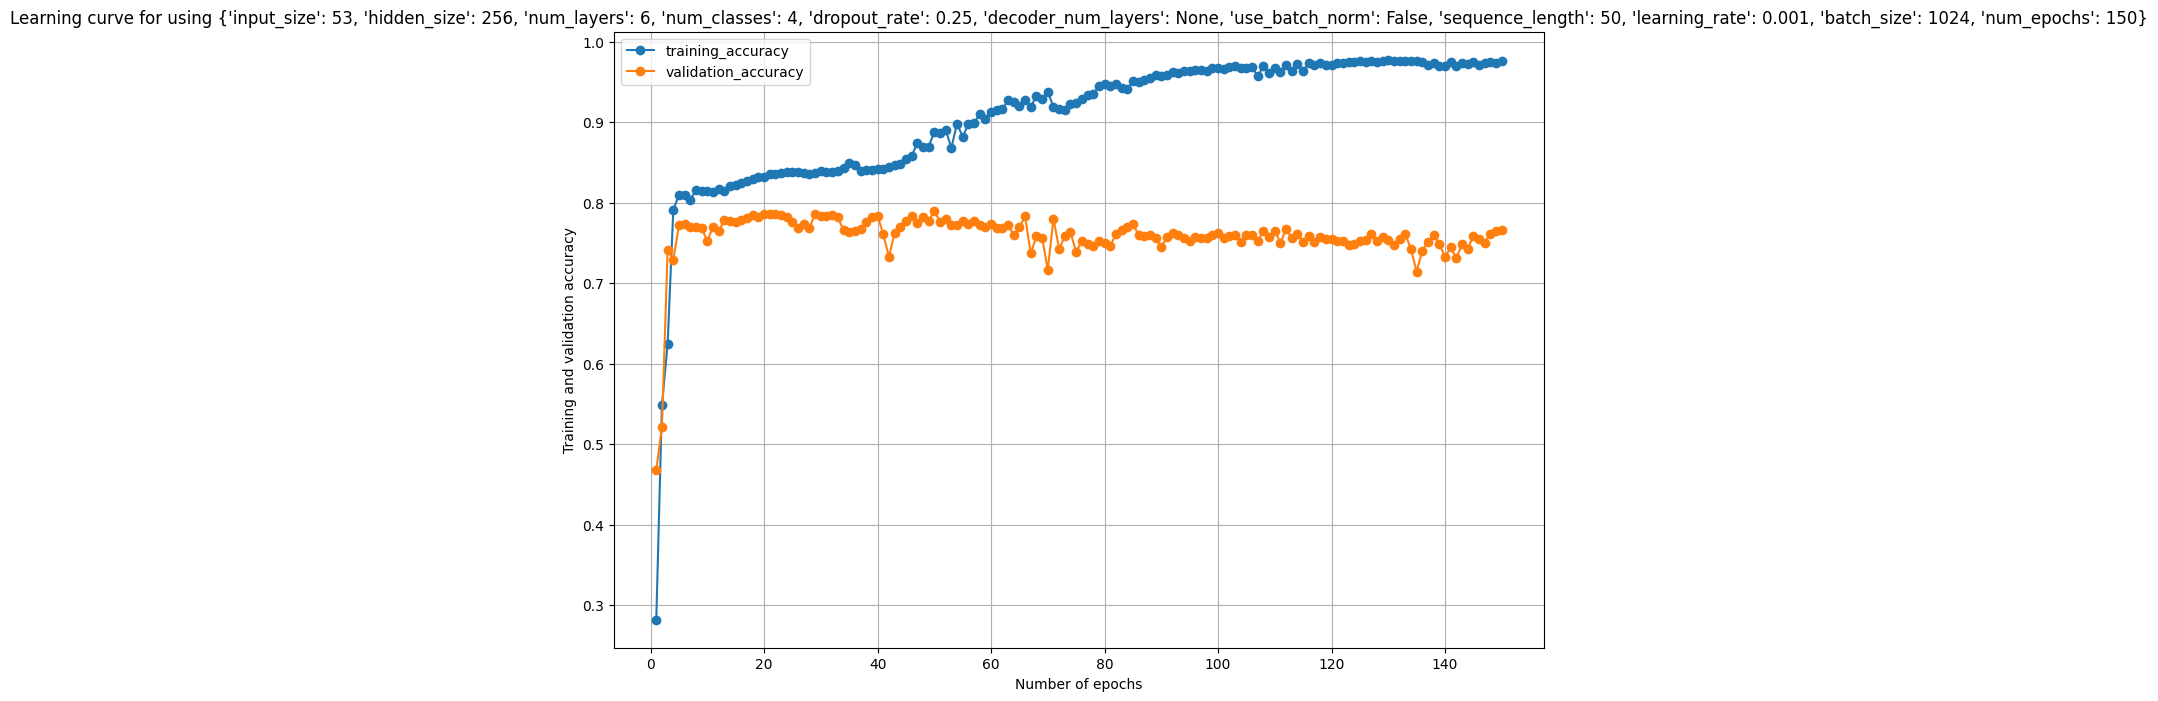

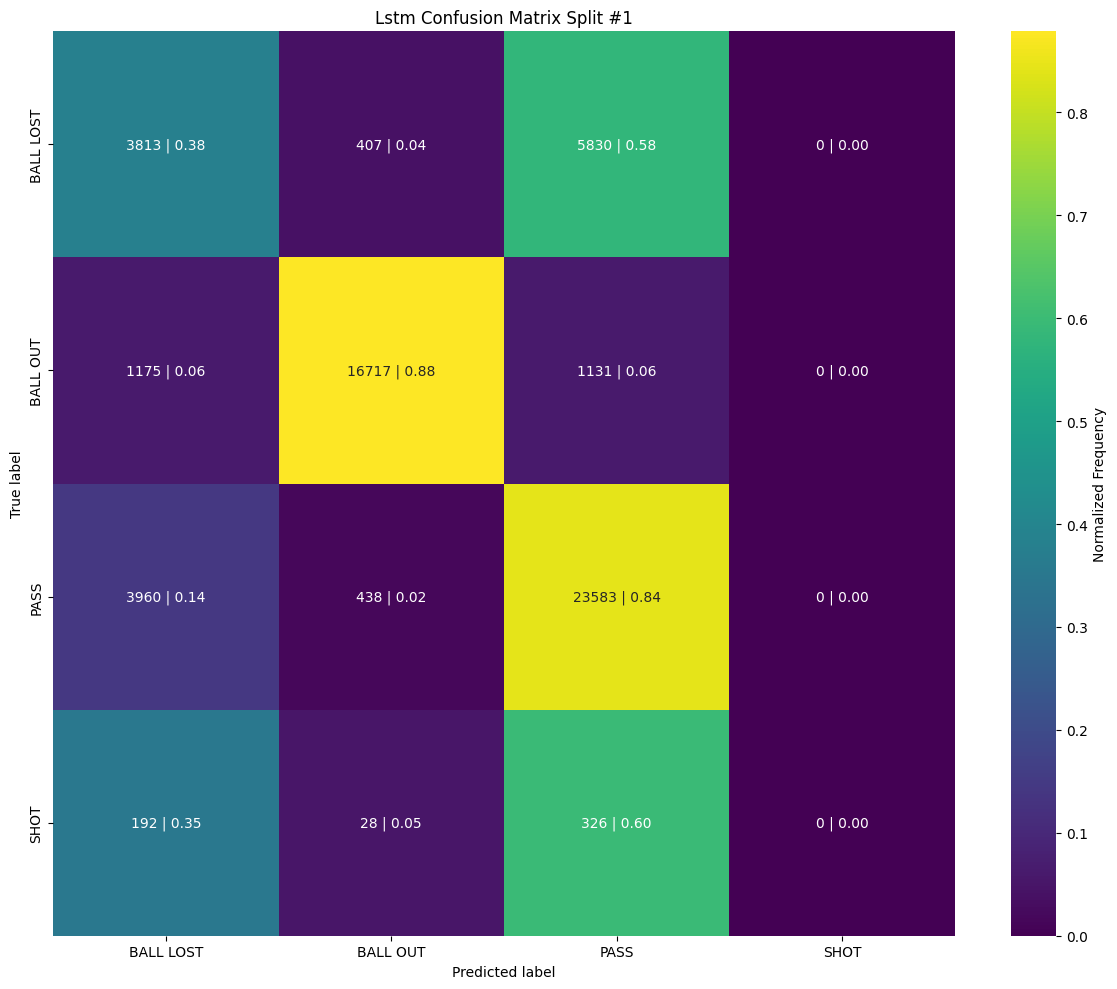

LSTM training accuracy: 97.59%
LSTM testing accuracy: 76.59%

LSTM testing precision: 75.78%
LSTM testing recall: 76.59%
LSTM testing f1: 76.03%




In [60]:
plot_accuracy_history(acc, title=f"using {str(lstm_params)}")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="LSTM")

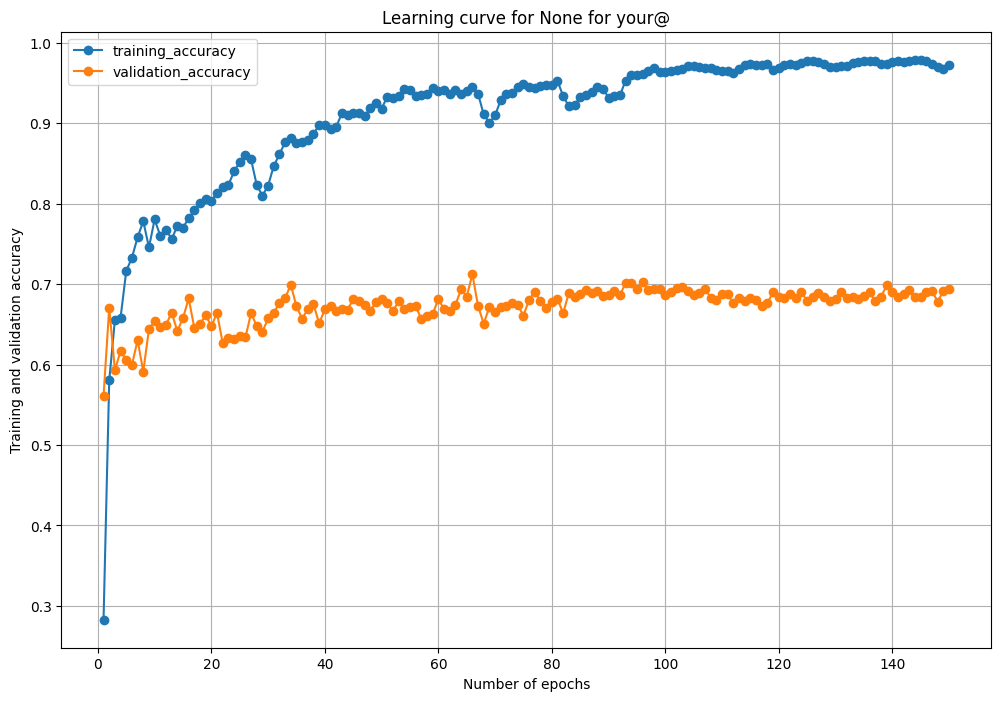

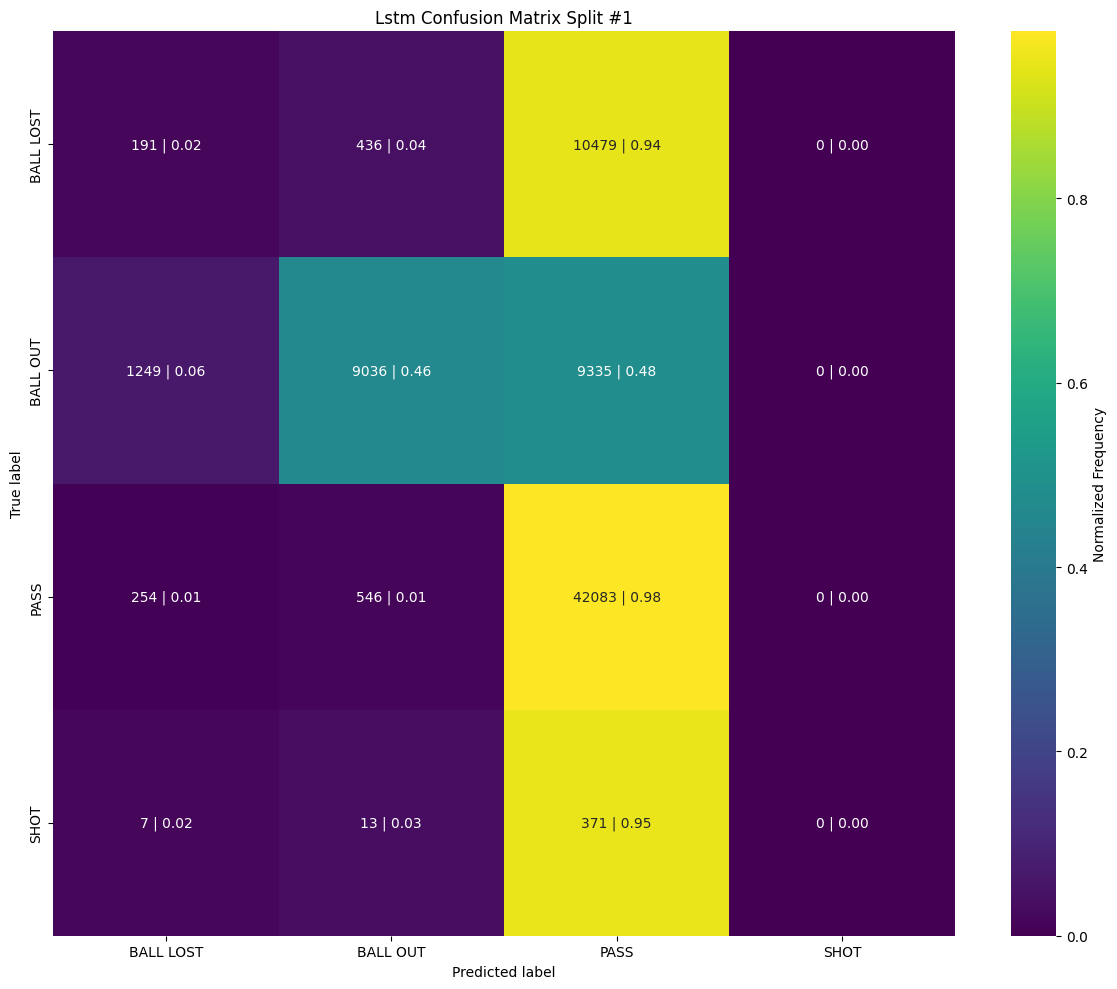

LSTM training accuracy: 97.21%
LSTM testing accuracy: 69.34%

LSTM testing precision: 64.73%
LSTM testing recall: 69.34%
LSTM testing f1: 62.99%




In [66]:
plot_accuracy_history(acc, title="None for your@")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="LSTM")

In [49]:
assert X_1_scaled.shape[1] == X_2_scaled.shape[1] == X_3_scaled.shape[1]
# assert np.unique(y_1).shape == np.unique(y_2).shape == np.unique(y_3).shape

gru_params = {
    "input_size": X_1_scaled.shape[1],
    "hidden_size" : 512,
    "num_layers" : 6,
    "num_classes" : np.unique(y_1_encoded).shape[0],
    "dropout_rate": 0.15,
    "decoder_num_layers": None,
    "use_batch_norm": False,
    "sequence_length": 50,
    "learning_rate": 0.001,
    "batch_size": 64,
    "num_epochs": 100
}
input_size = gru_params["input_size"]
sequence_length = gru_params["sequence_length"]
learning_rate = gru_params["learning_rate"]
batch_size = gru_params["batch_size"]
num_epochs = gru_params["num_epochs"]

In [50]:
class ToTensorSequential:
    def __call__(self, sample):
        X, y = sample['X'], sample['y']
        # Convert both features and labels to tensors
        return {
            'X': torch.tensor(X, dtype=torch.float32),
            'y': torch.tensor(y, dtype=torch.long)
        }
        
transform = v2.Compose([
    ToTensorSequential(),
])


class SequenceDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        sample = {"X": self.X[idx], "y": self.y[idx]}
        if self.transform:
            sample = self.transform(sample)
        return sample["X"], sample["y"]


In [51]:
X_comb = np.concatenate([X_1_scaled, X_2_scaled])
y_comb = np.concatenate((y_1_encoded, y_2_encoded))

X_comb_reshaped = X_comb.reshape(-1, sequence_length, input_size).astype(float)
y_comb_reshaped = y_comb.reshape(-1, sequence_length)

X_3_reshaped = X_3_scaled.reshape(-1, sequence_length, input_size).astype(float)
y_3_reshaped = y_3_encoded.reshape(-1, sequence_length) 

train_dataset = SequenceDataset(X_comb_reshaped, y_comb_reshaped, transform=transform)
validation_dataset = SequenceDataset(X_3_reshaped, y_3_reshaped, transform=transform)

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size, 
    shuffle=False,
)

validation_loader = DataLoader(
    dataset=validation_dataset, 
    batch_size=batch_size, 
    shuffle=False,
)

In [52]:
gru_model = get_model(GRU, params=gru_params).to(device)
gru_model

GRU(
  (encoder): Encoder(
    (input_bn): LayerNorm((140,), eps=1e-05, elementwise_affine=True)
    (gru): GRU(140, 512, num_layers=6, batch_first=True, dropout=0.15)
  )
  (decoder): Decoder(
    (gru): GRU(4, 512, num_layers=6, batch_first=True, dropout=0.15)
    (hidden_bn): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (fc): Sequential(
      (0): Linear(in_features=512, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.15, inplace=False)
      (4): Linear(in_features=512, out_features=4, bias=True)
    )
  )
)

In [53]:
# a, b, c = test_model(gru_model, validation_loader, nn.CrossEntropyLoss(weight=torch.from_numpy(weight_2).to(device)), device)

In [54]:
acc, y_train, y_train_pred, y_true, y_pred = train_model(gru_model, train_loader, validation_loader, num_epochs, "adam", nn.CrossEntropyLoss(weight=weights), learning_rate, device, is_rnn=True)

Epoch   1/100: Train accuracy: 60.88% | Val accuracy: 78.70% | Train loss: 0.7900 | Val loss: 0.4464 | learning rate: 0.001000 | Precision: 66.48% | Recall: 78.70% | F1: 72.07%
Epoch   2/100: Train accuracy: 79.65% | Val accuracy: 81.43% | Train loss: 0.3556 | Val loss: 0.2910 | learning rate: 0.001000 | Precision: 69.37% | Recall: 81.43% | F1: 74.70%
Epoch   3/100: Train accuracy: 81.51% | Val accuracy: 81.98% | Train loss: 0.2775 | Val loss: 0.2778 | learning rate: 0.001000 | Precision: 69.89% | Recall: 81.98% | F1: 75.23%
Epoch   4/100: Train accuracy: 82.15% | Val accuracy: 82.17% | Train loss: 0.2581 | Val loss: 0.2802 | learning rate: 0.001000 | Precision: 69.89% | Recall: 82.17% | F1: 75.38%
Epoch   5/100: Train accuracy: 82.19% | Val accuracy: 81.85% | Train loss: 0.2524 | Val loss: 0.3152 | learning rate: 0.001000 | Precision: 69.30% | Recall: 81.85% | F1: 75.01%
Epoch   6/100: Train accuracy: 82.18% | Val accuracy: 81.63% | Train loss: 0.2418 | Val loss: 0.2822 | learning rat

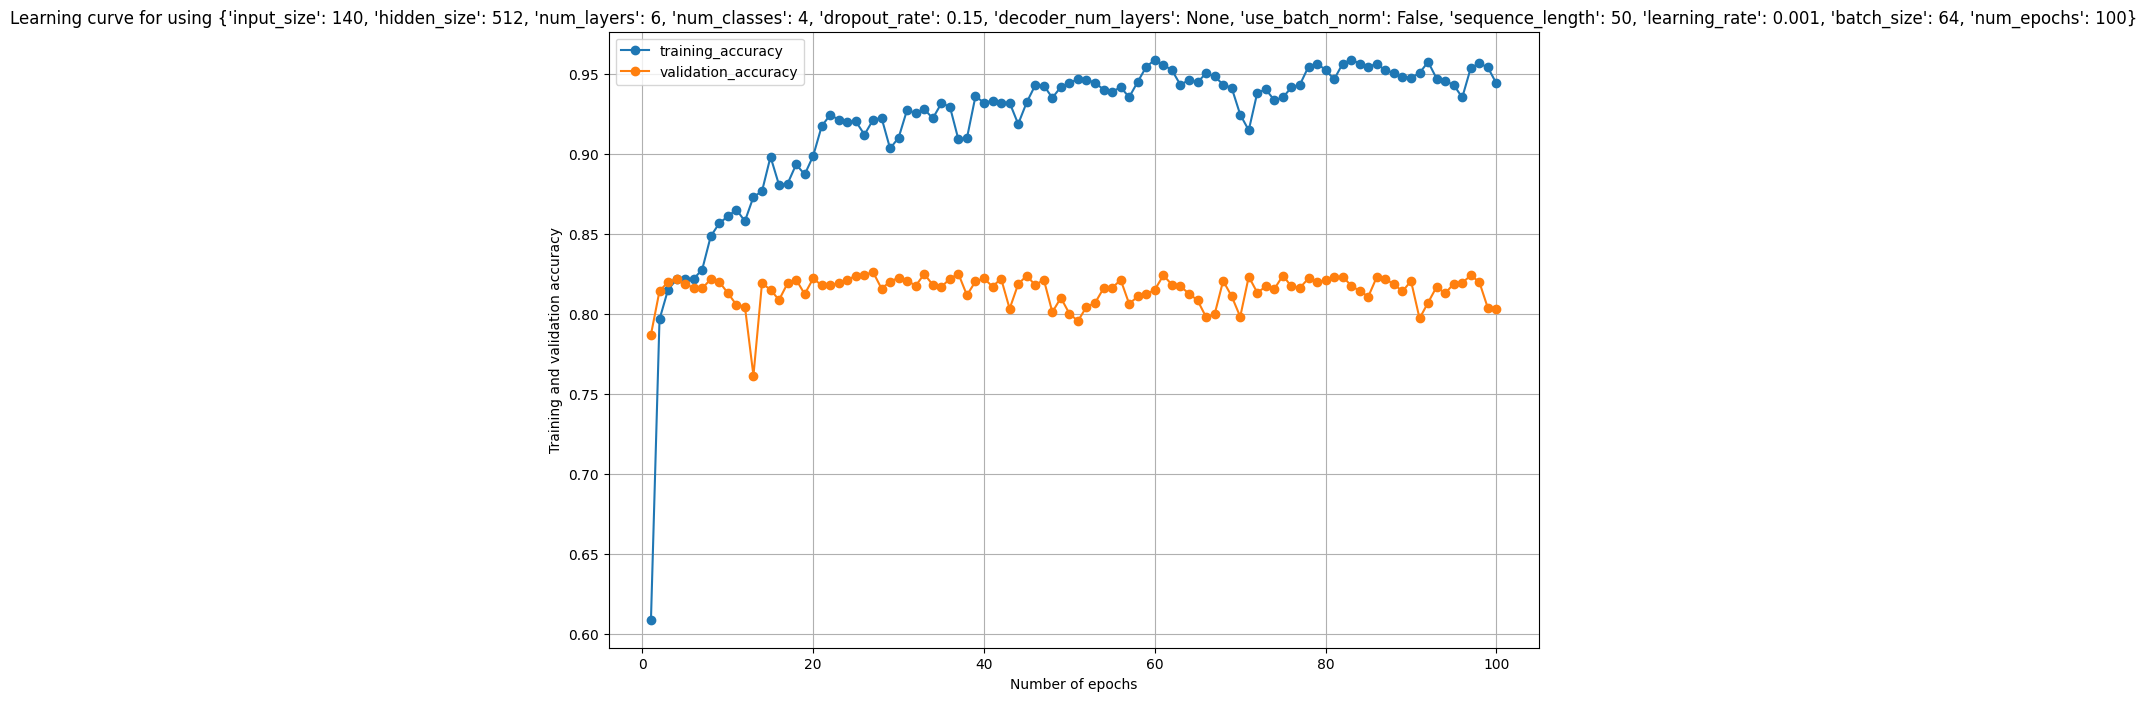

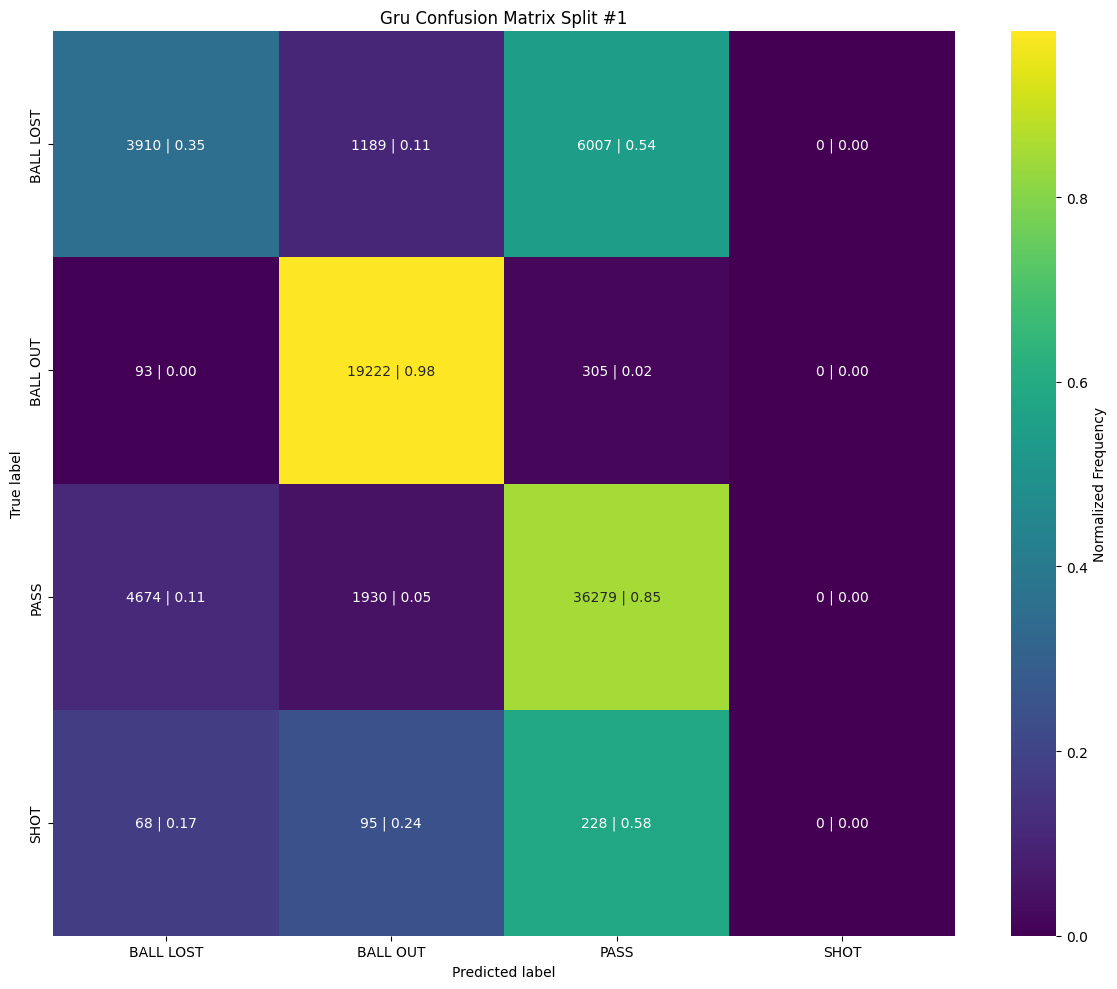

GRU training accuracy: 94.39%
GRU testing accuracy: 80.29%

GRU testing precision: 78.52%
GRU testing recall: 80.29%
GRU testing f1: 79.21%




In [55]:
plot_accuracy_history(acc, title=f"using {str(gru_params)}")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

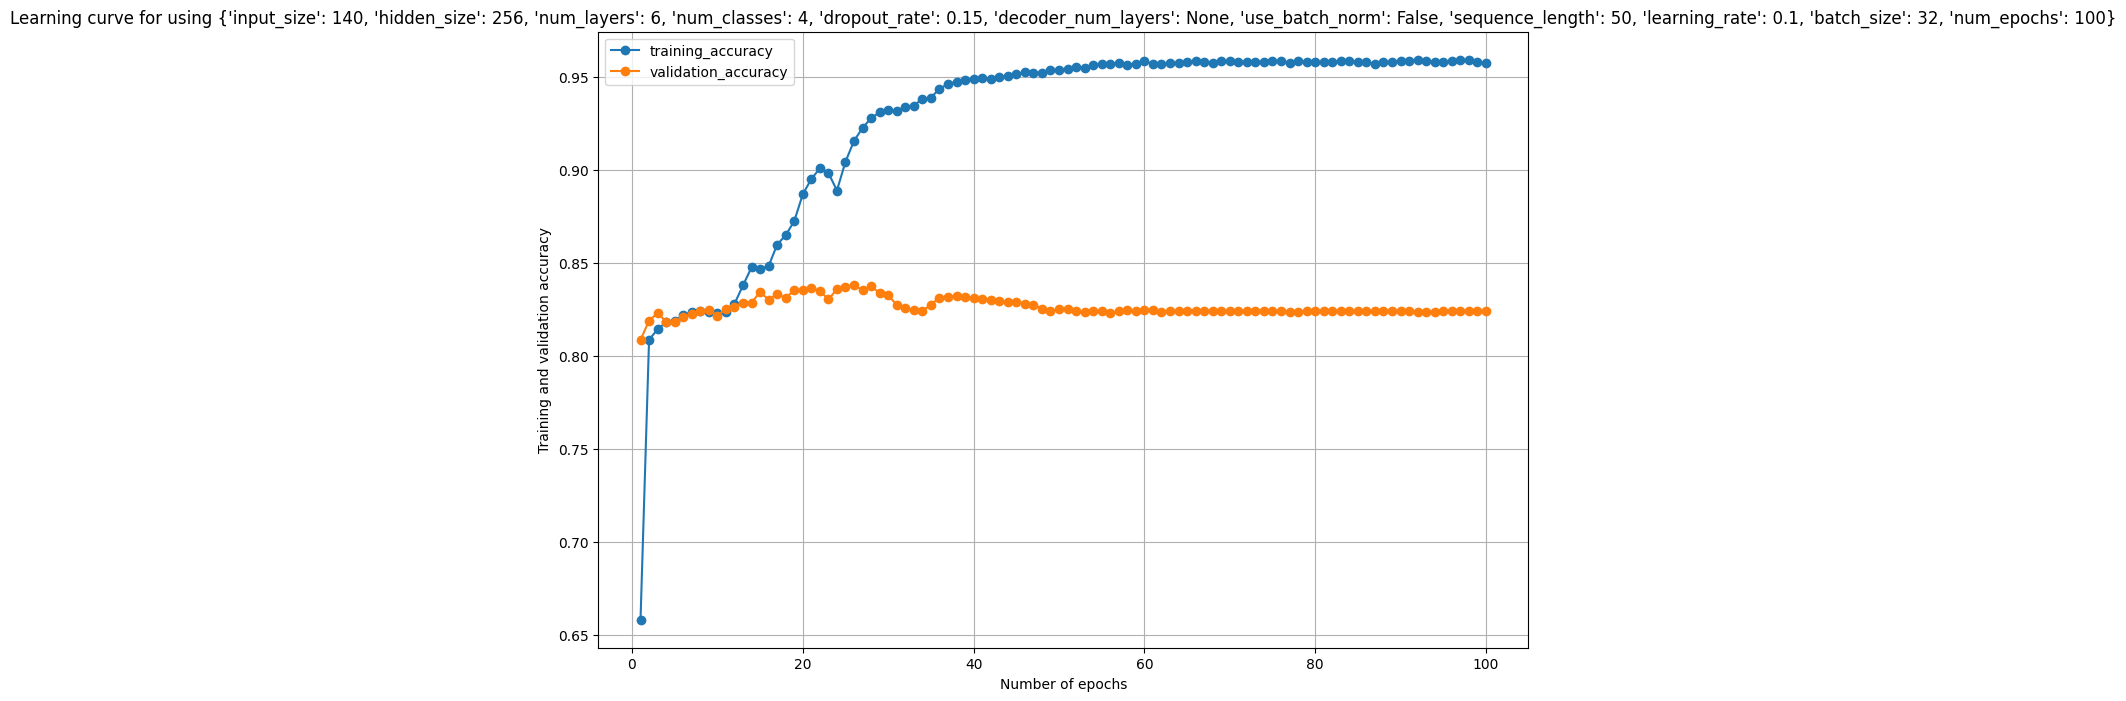

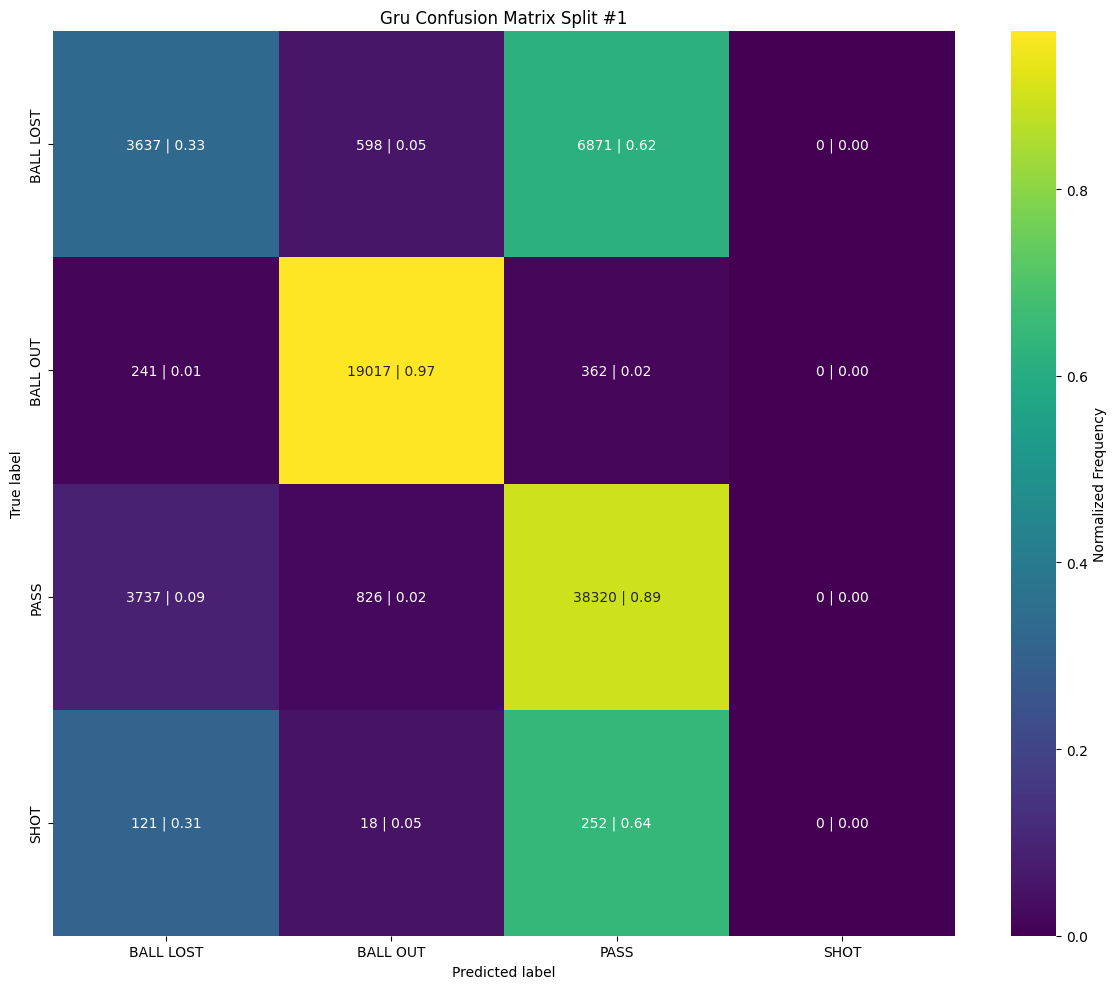

GRU training accuracy: 95.76%
GRU testing accuracy: 82.40%

GRU testing precision: 80.18%
GRU testing recall: 82.40%
GRU testing f1: 81.03%




In [55]:
plot_accuracy_history(acc, title=f"using {str(gru_params)}")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

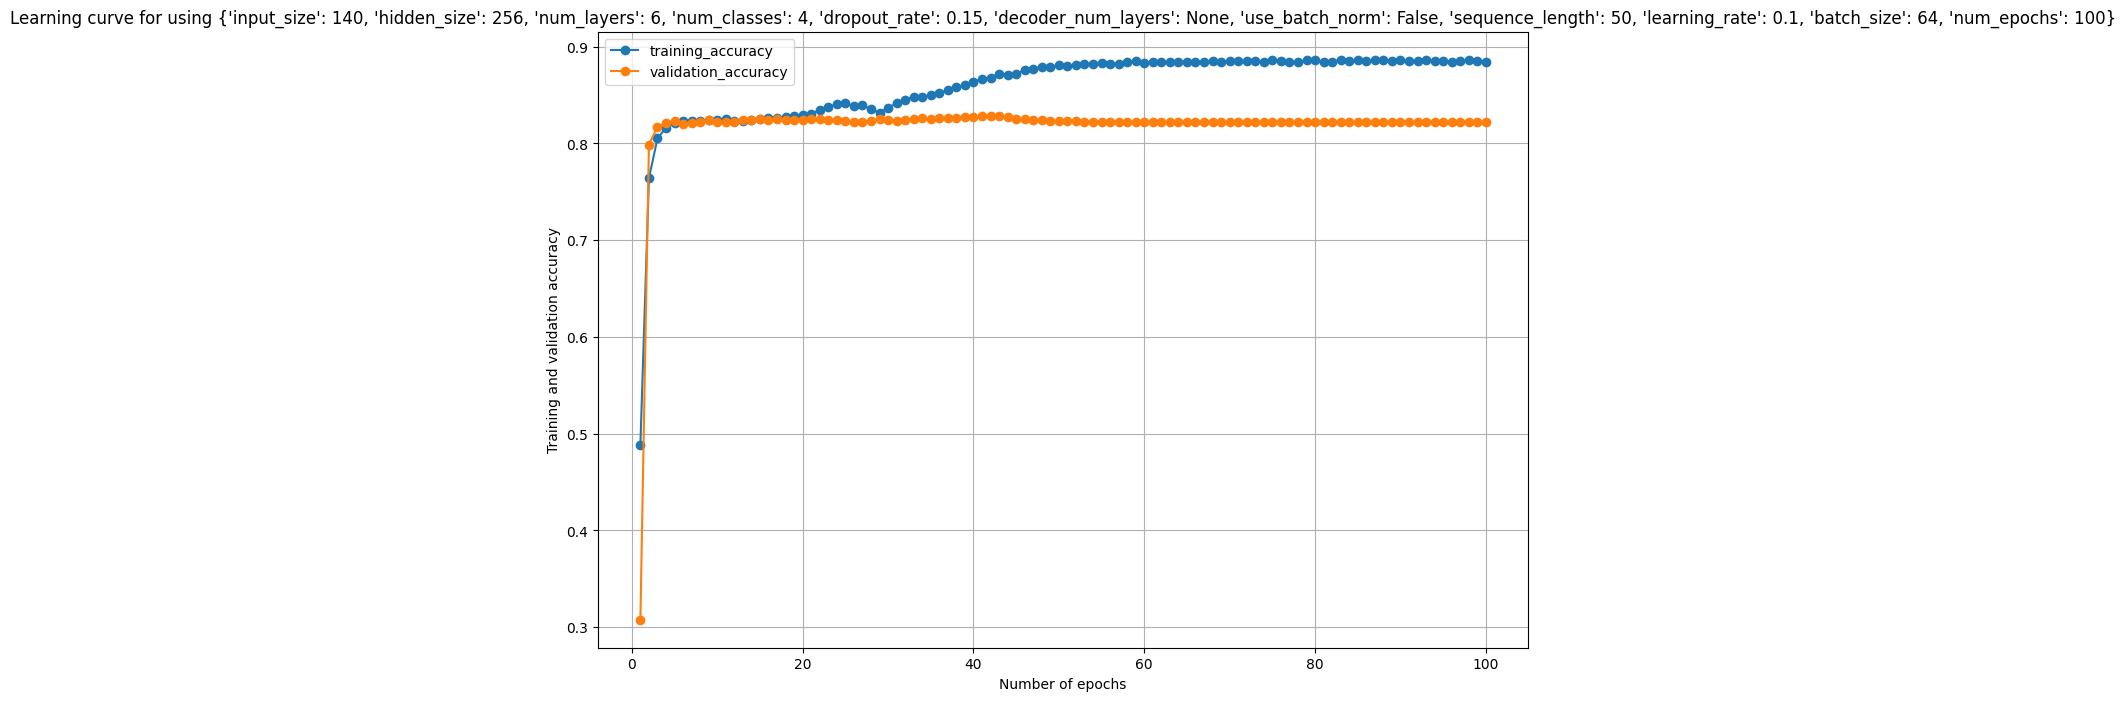

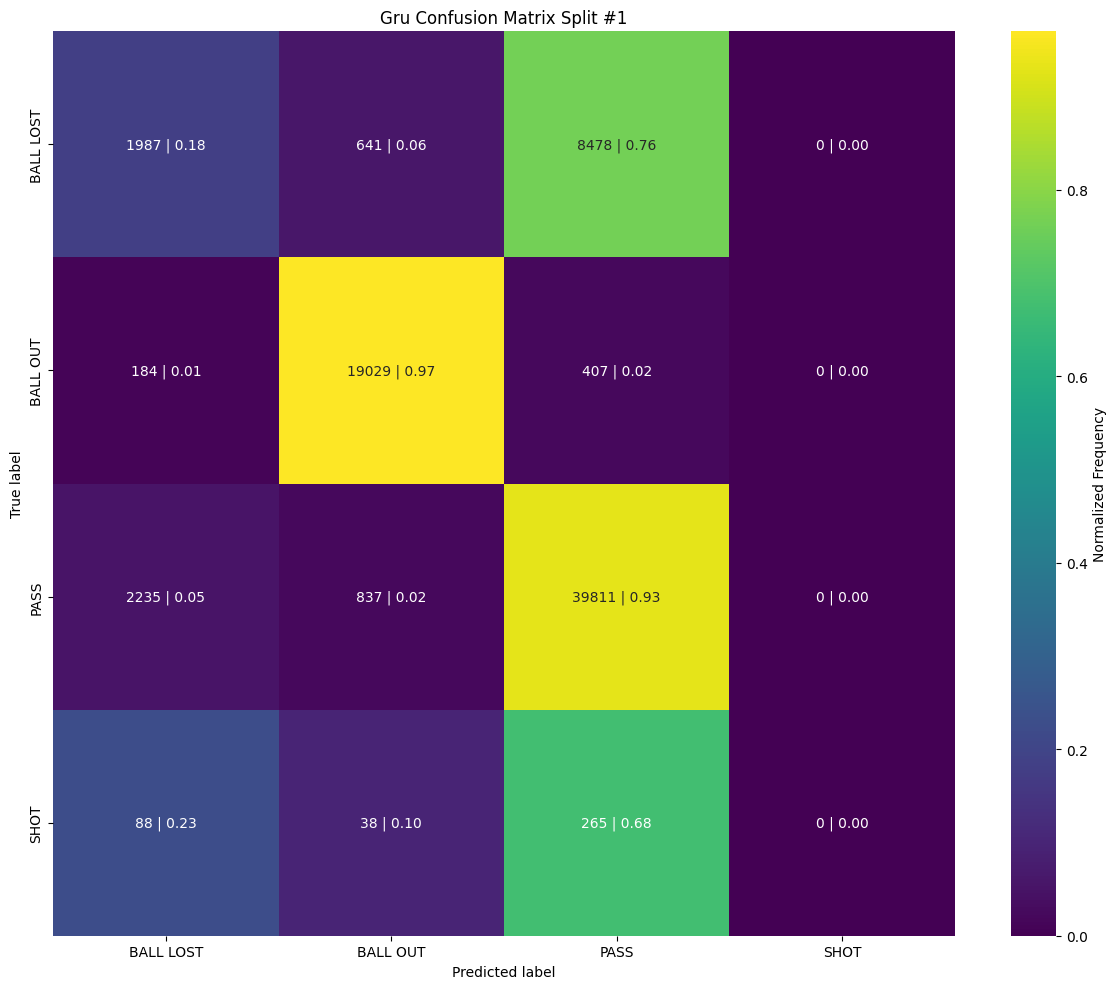

GRU training accuracy: 88.44%
GRU testing accuracy: 82.20%

GRU testing precision: 78.31%
GRU testing recall: 82.20%
GRU testing f1: 79.18%




In [55]:
plot_accuracy_history(acc, title=f"using {str(gru_params)}")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

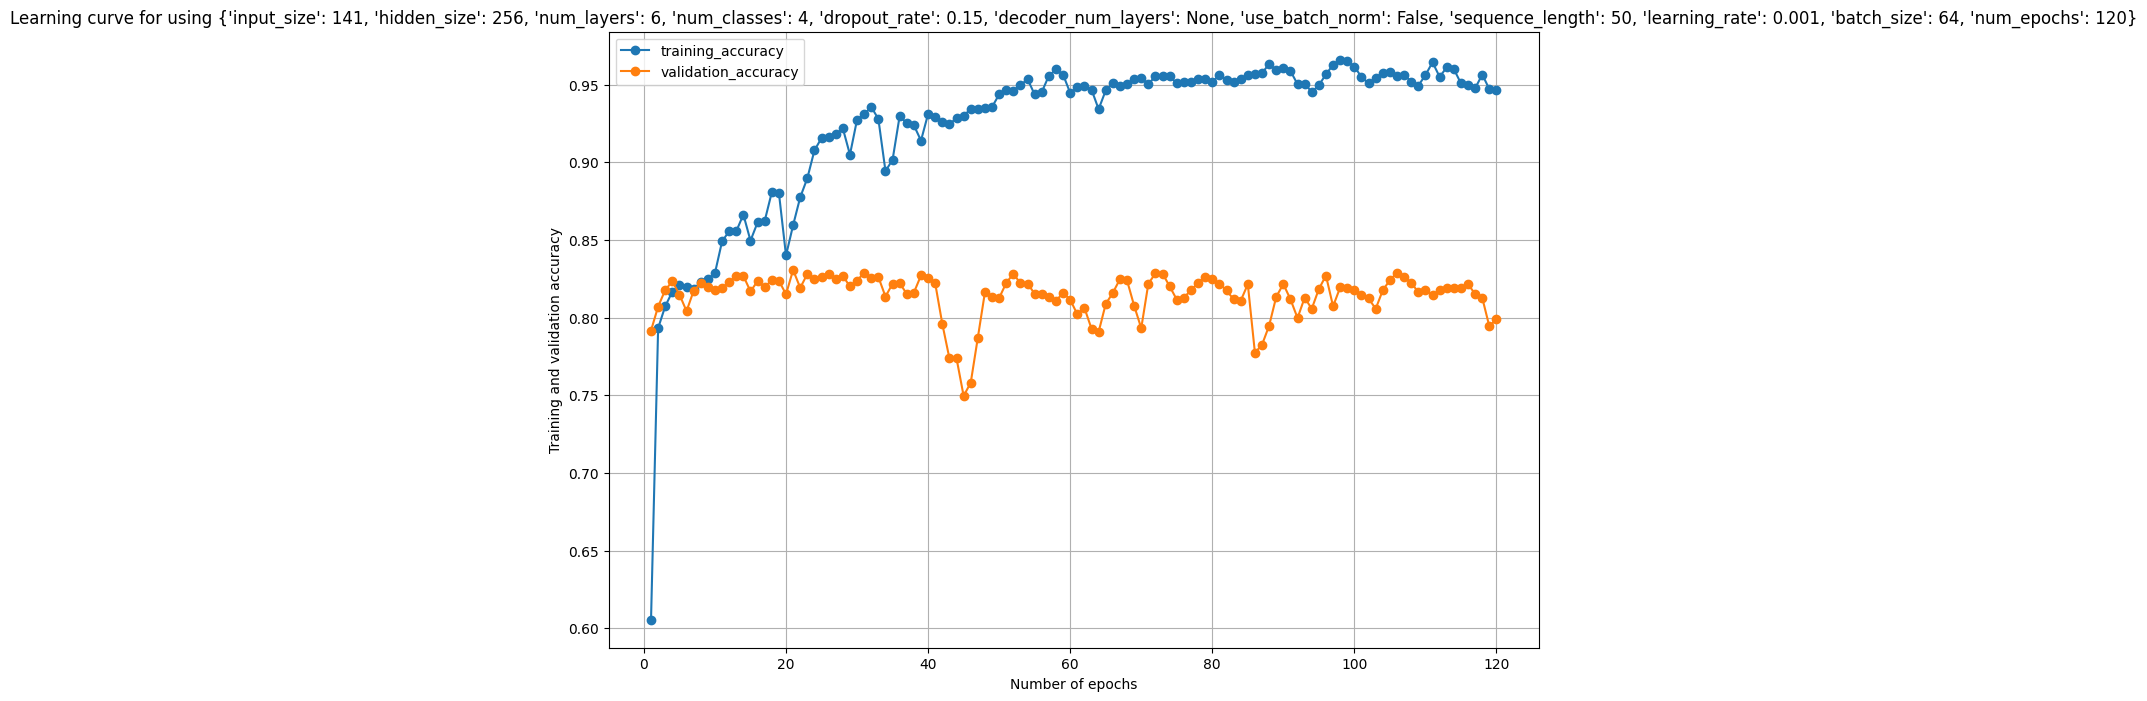

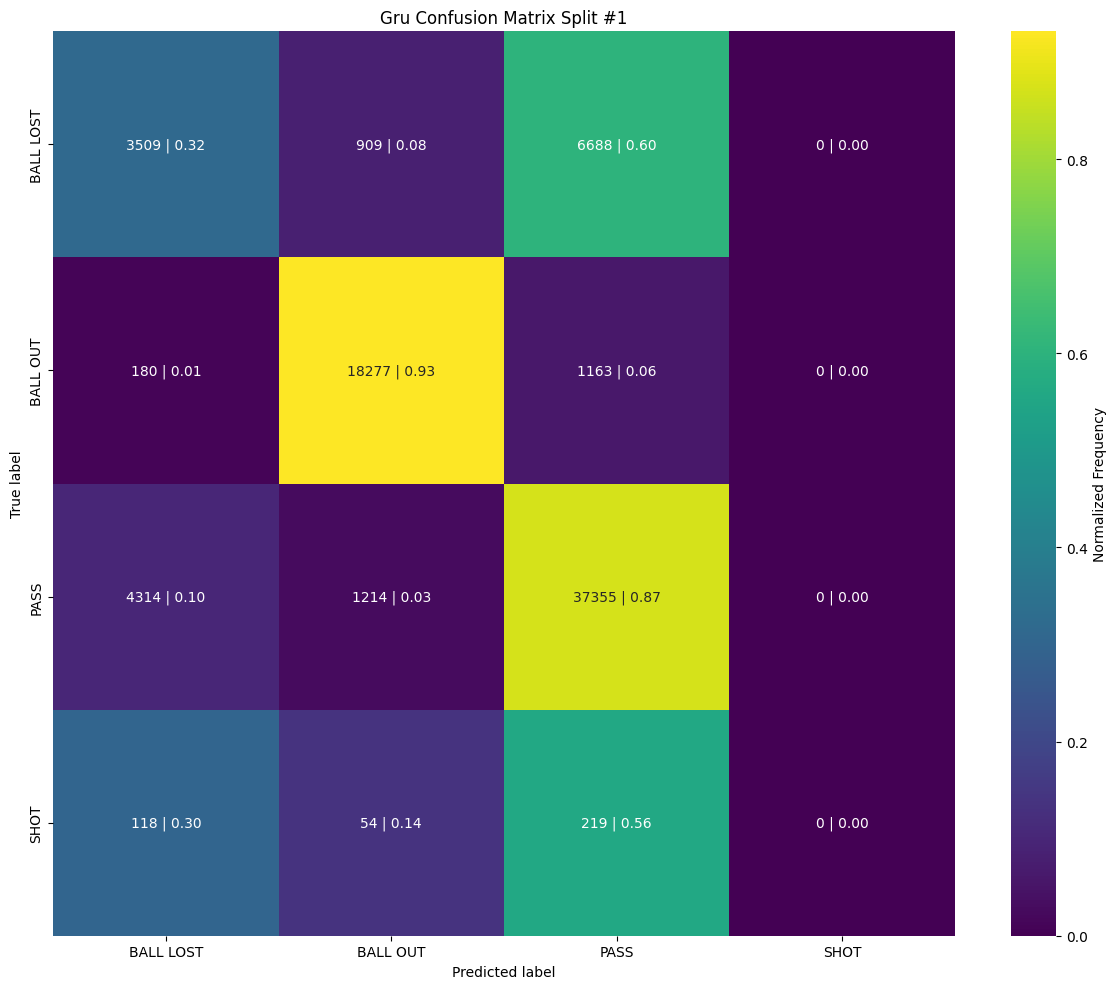

GRU training accuracy: 94.64%
GRU testing accuracy: 79.92%

GRU testing precision: 77.83%
GRU testing recall: 79.92%
GRU testing f1: 78.69%




In [54]:
plot_accuracy_history(acc, title=f"using {str(gru_params)}")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

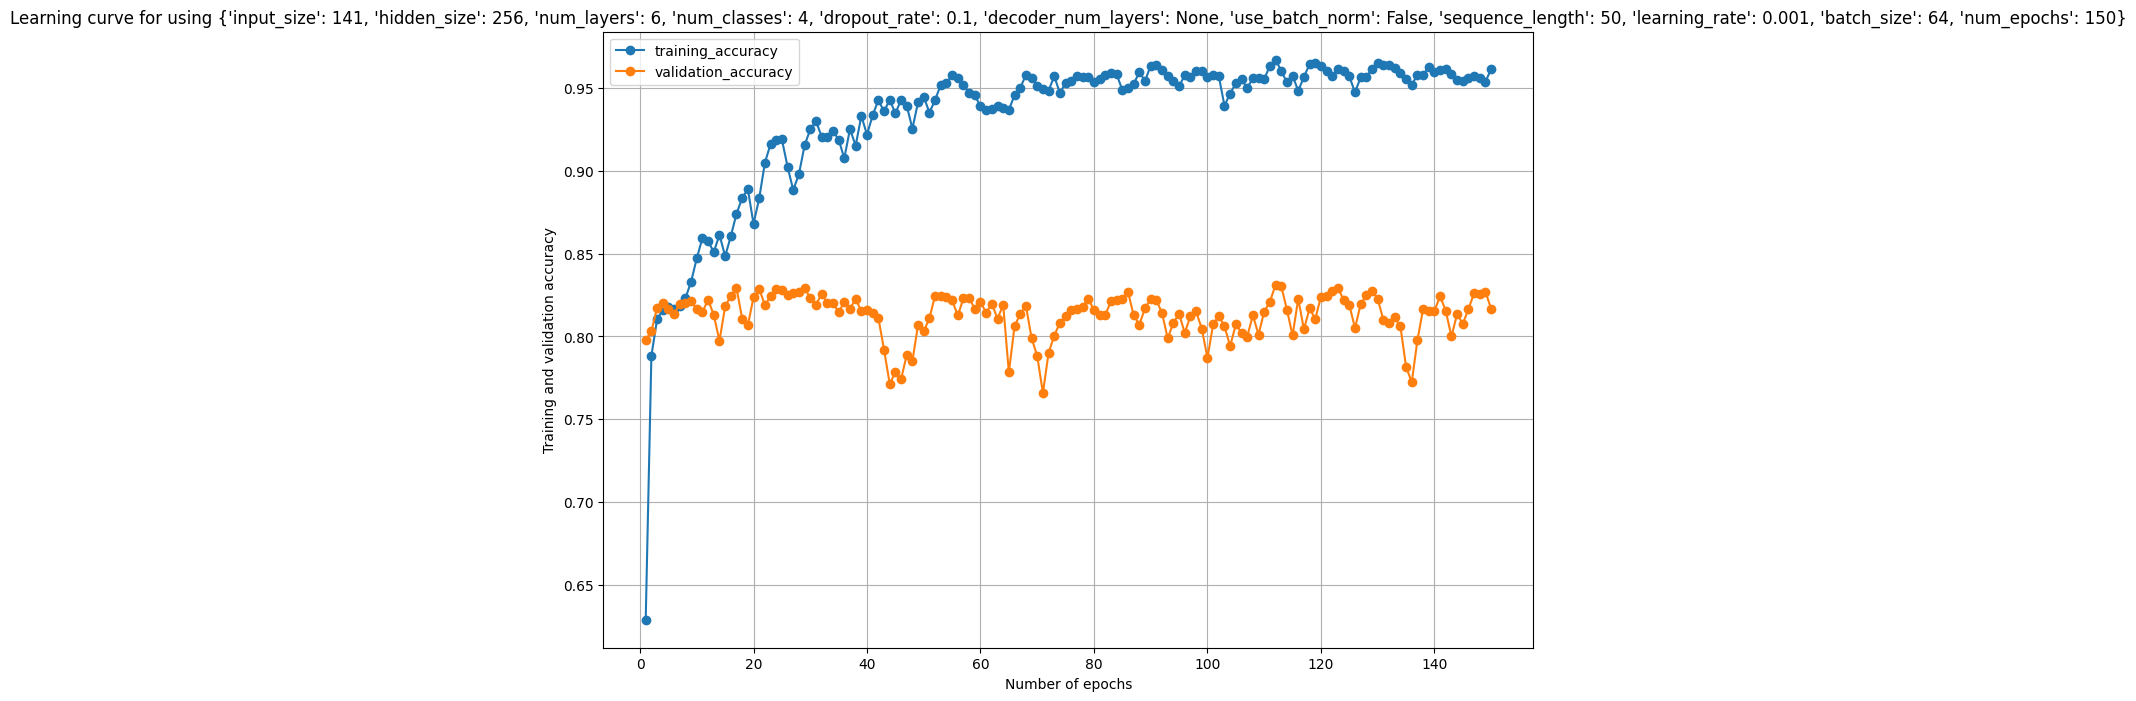

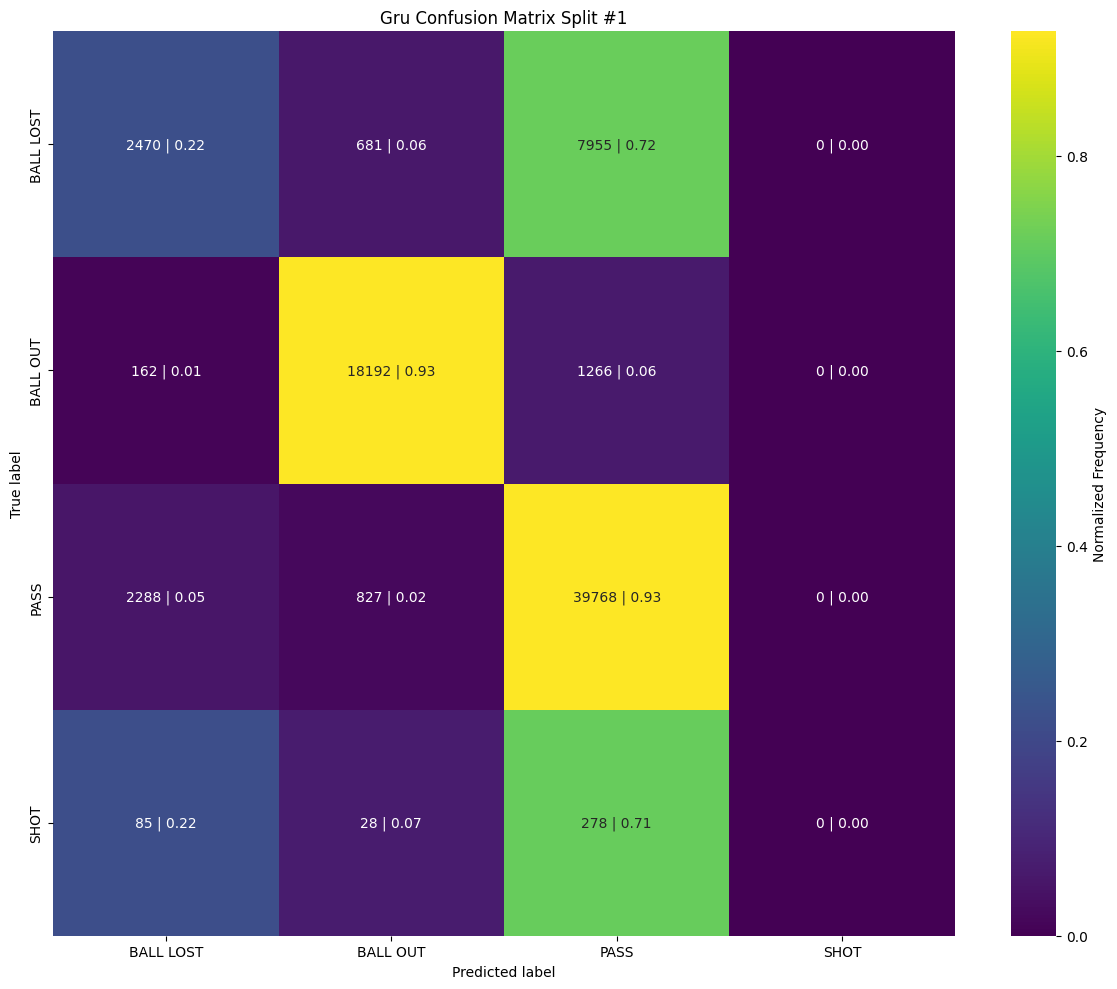

GRU training accuracy: 96.14%
GRU testing accuracy: 81.66%

GRU testing precision: 78.63%
GRU testing recall: 81.66%
GRU testing f1: 79.14%




In [54]:
plot_accuracy_history(acc, title=f"using {str(gru_params)}")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

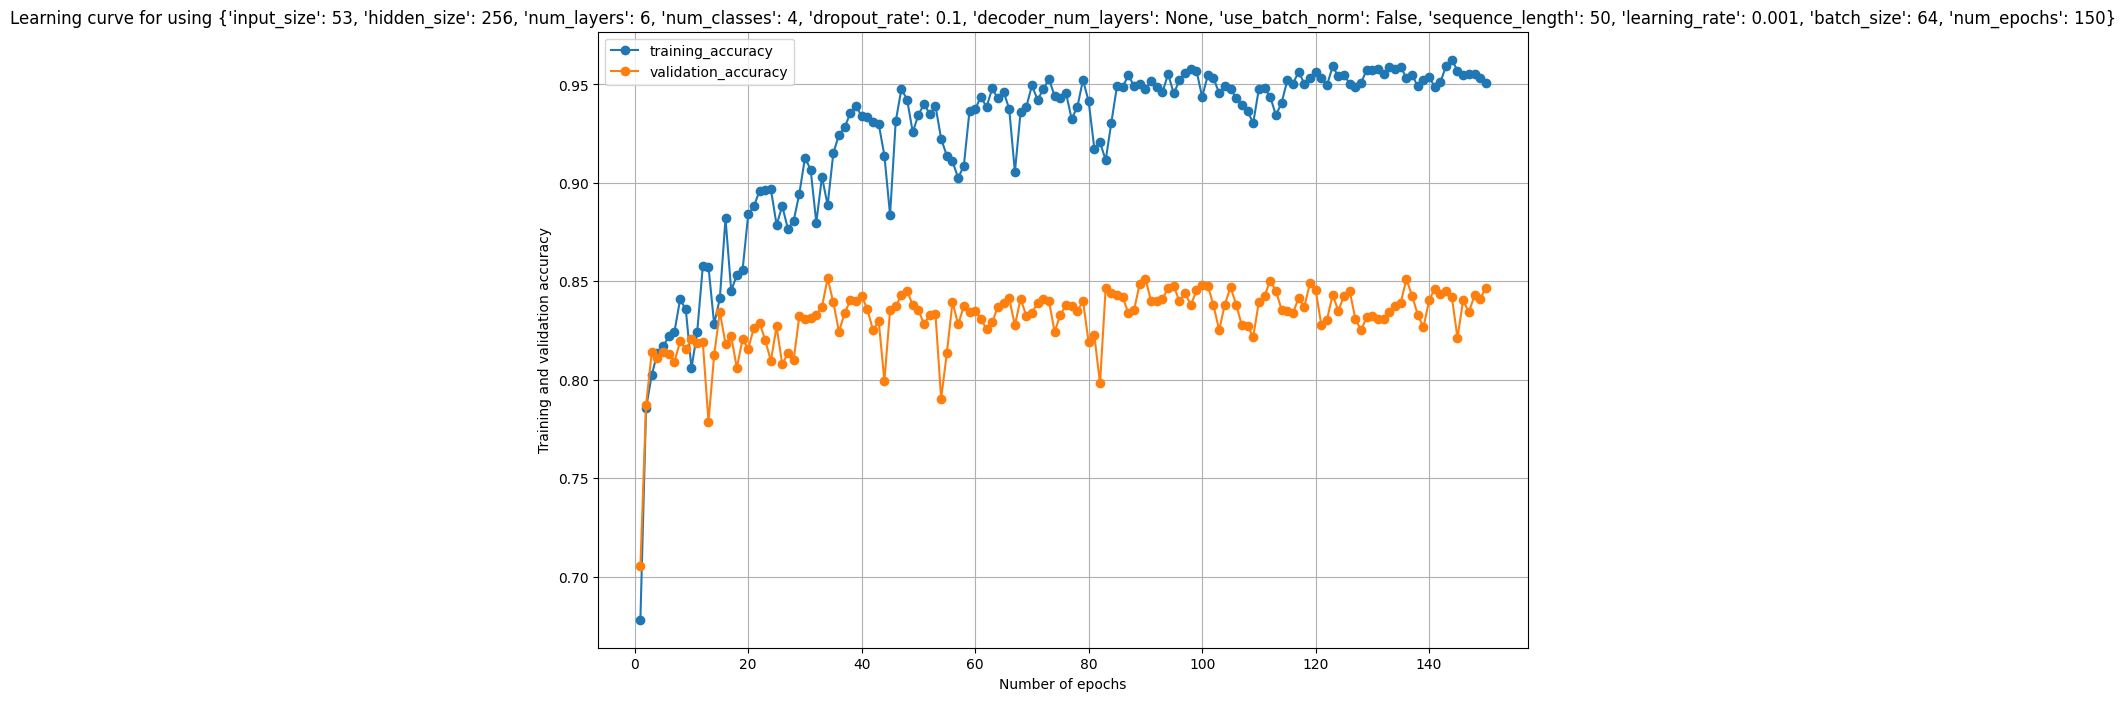

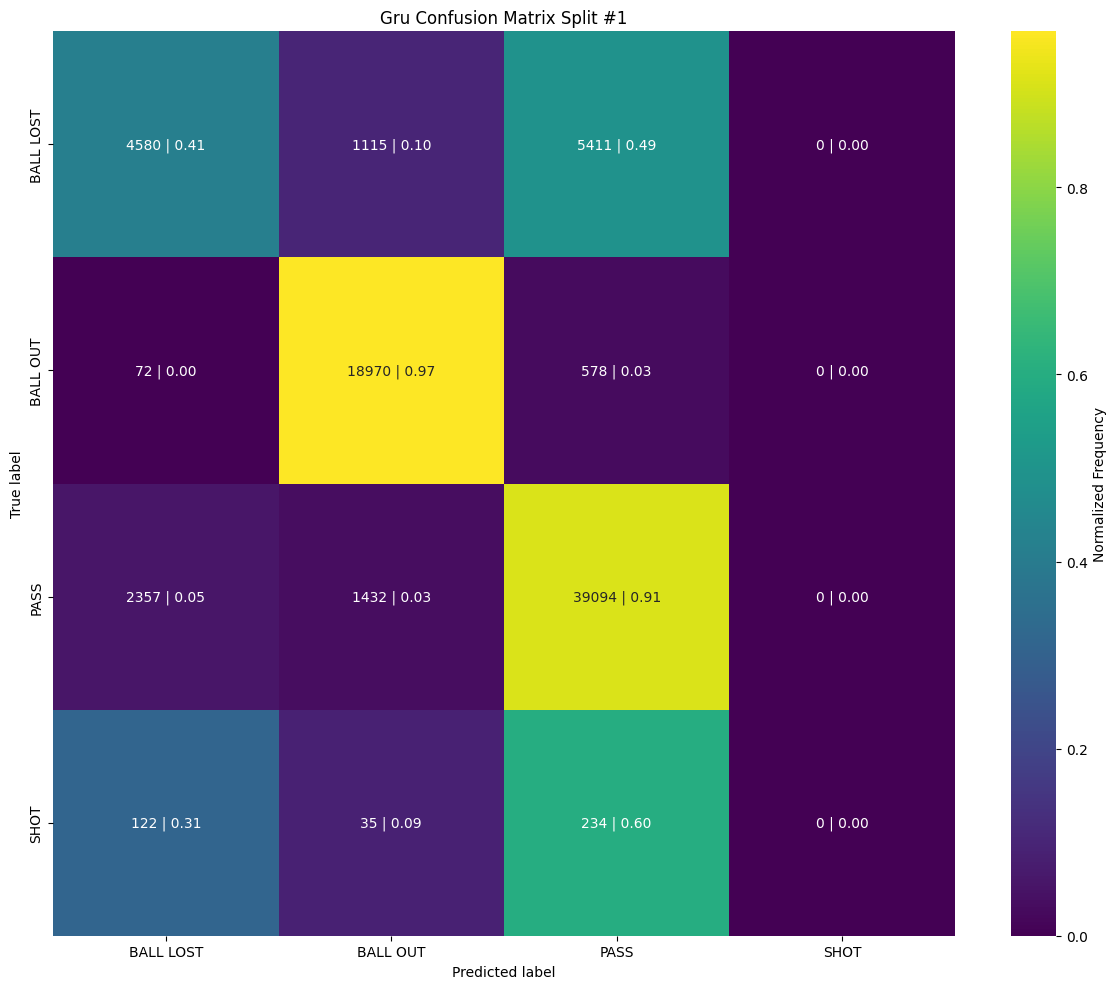

GRU training accuracy: 95.07%
GRU testing accuracy: 84.65%

GRU testing precision: 82.97%
GRU testing recall: 84.65%
GRU testing f1: 83.34%




In [54]:
plot_accuracy_history(acc, title=f"using {str(gru_params)}")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

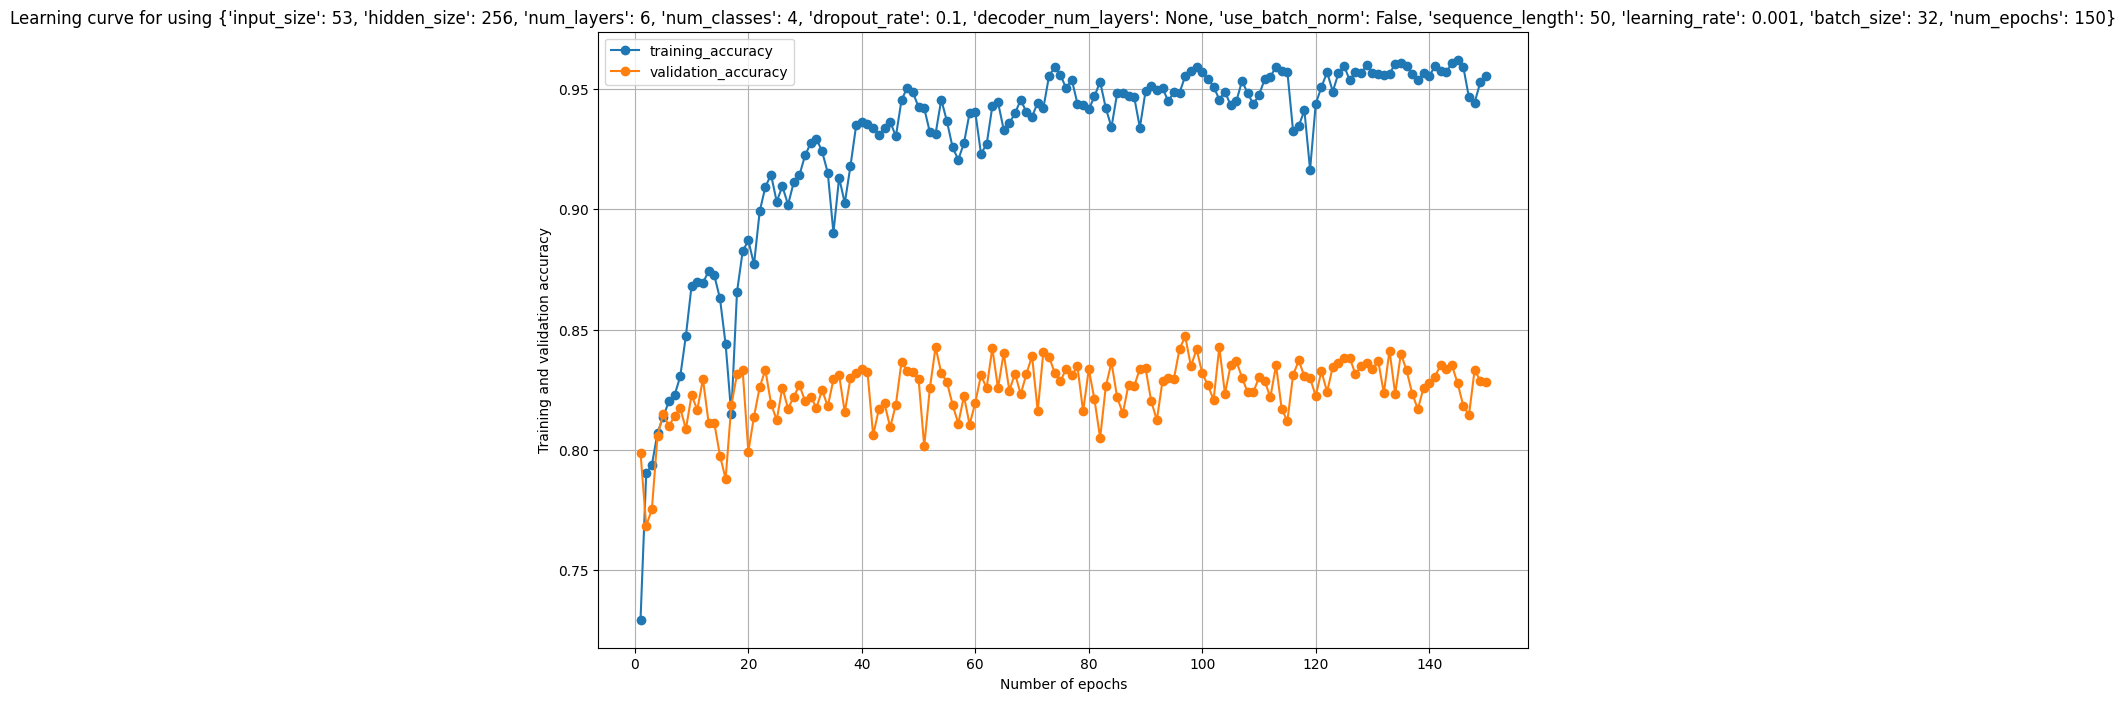

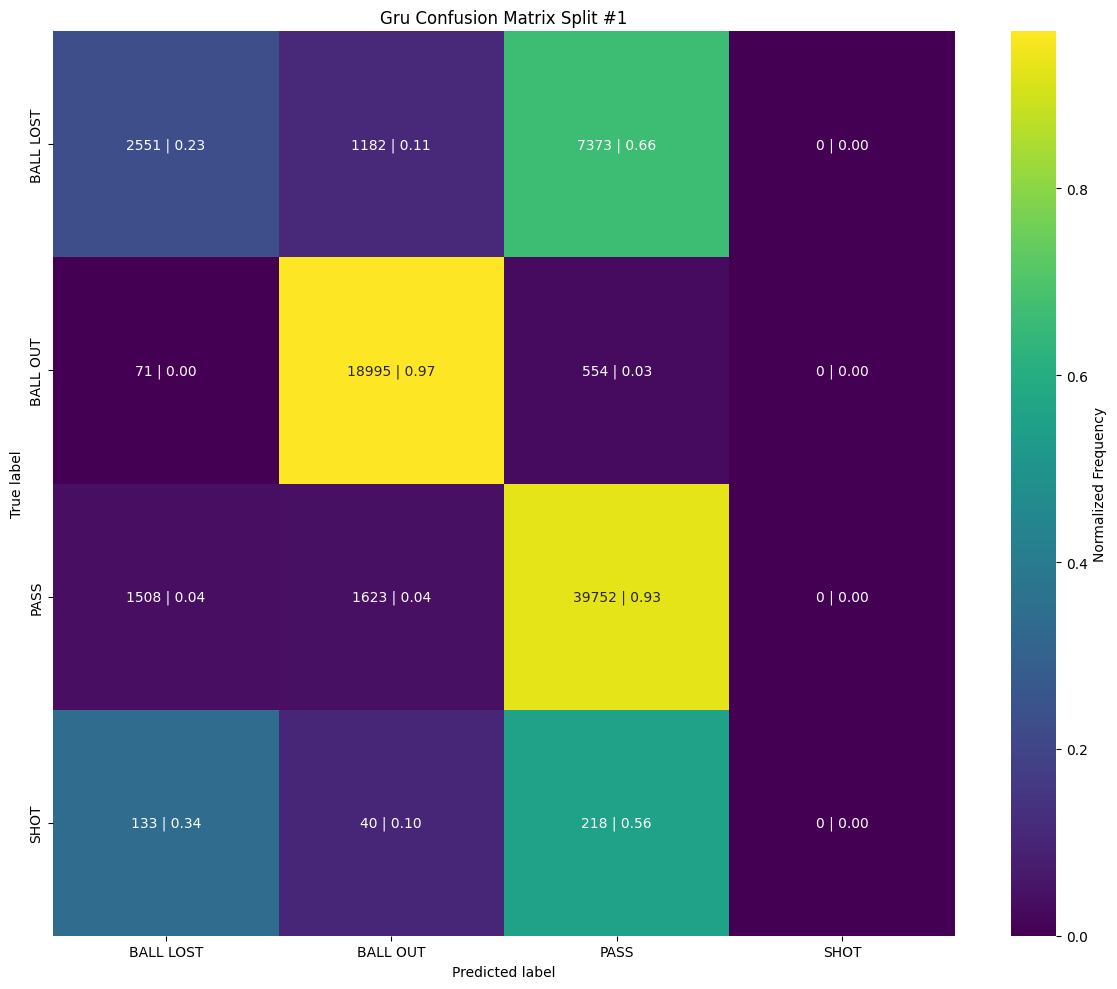

GRU training accuracy: 95.53%
GRU testing accuracy: 82.84%

GRU testing precision: 80.14%
GRU testing recall: 82.84%
GRU testing f1: 80.03%




In [54]:
plot_accuracy_history(acc, title=f"using {str(gru_params)}")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

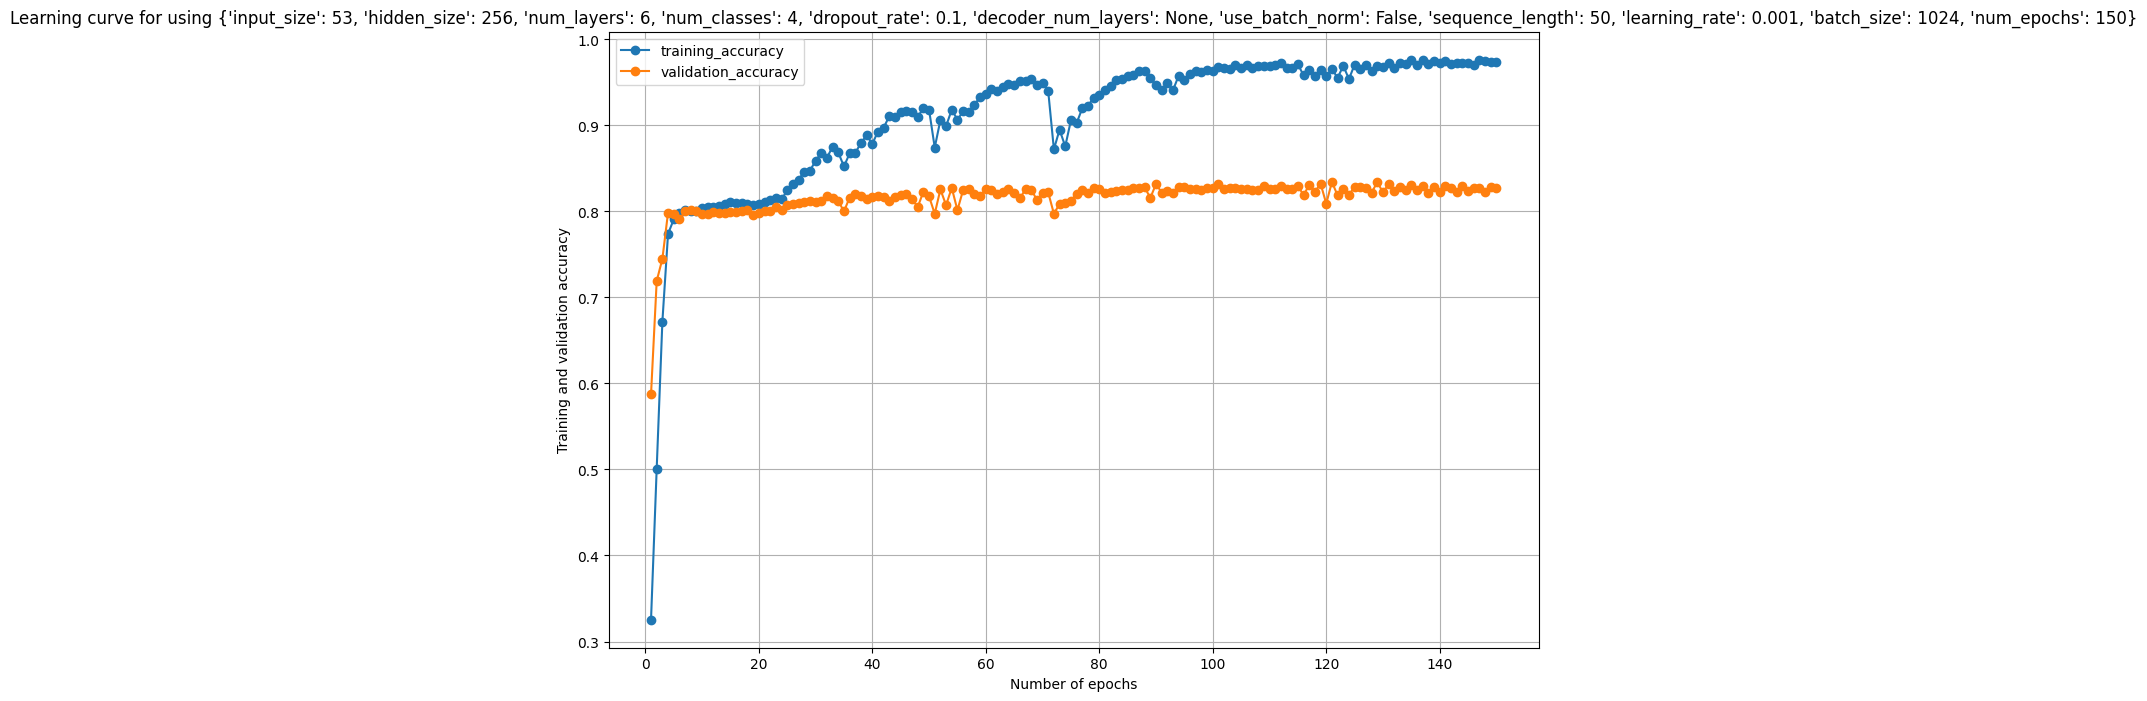

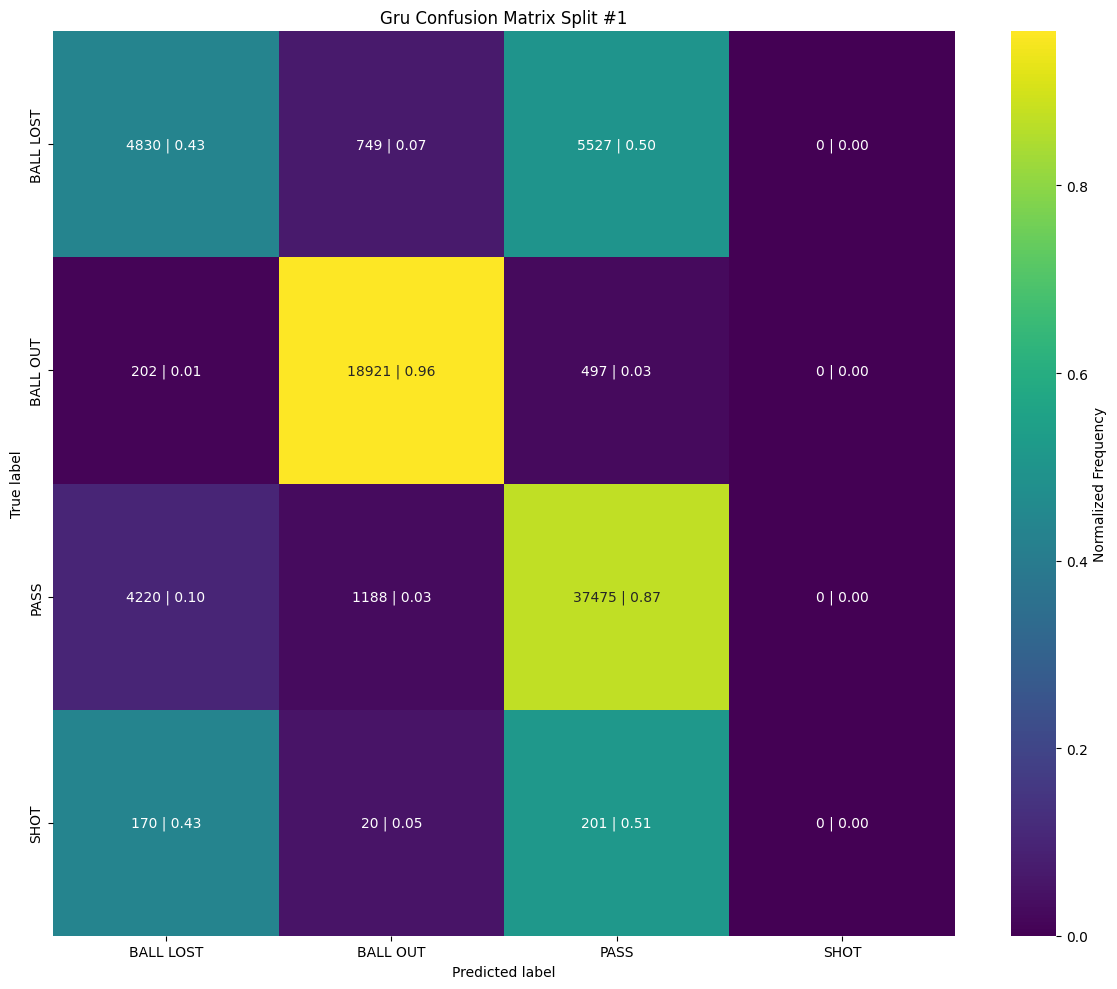

GRU training accuracy: 97.37%
GRU testing accuracy: 82.74%

GRU testing precision: 81.42%
GRU testing recall: 82.74%
GRU testing f1: 82.00%




In [54]:
plot_accuracy_history(acc, title=f"using {str(gru_params)}")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

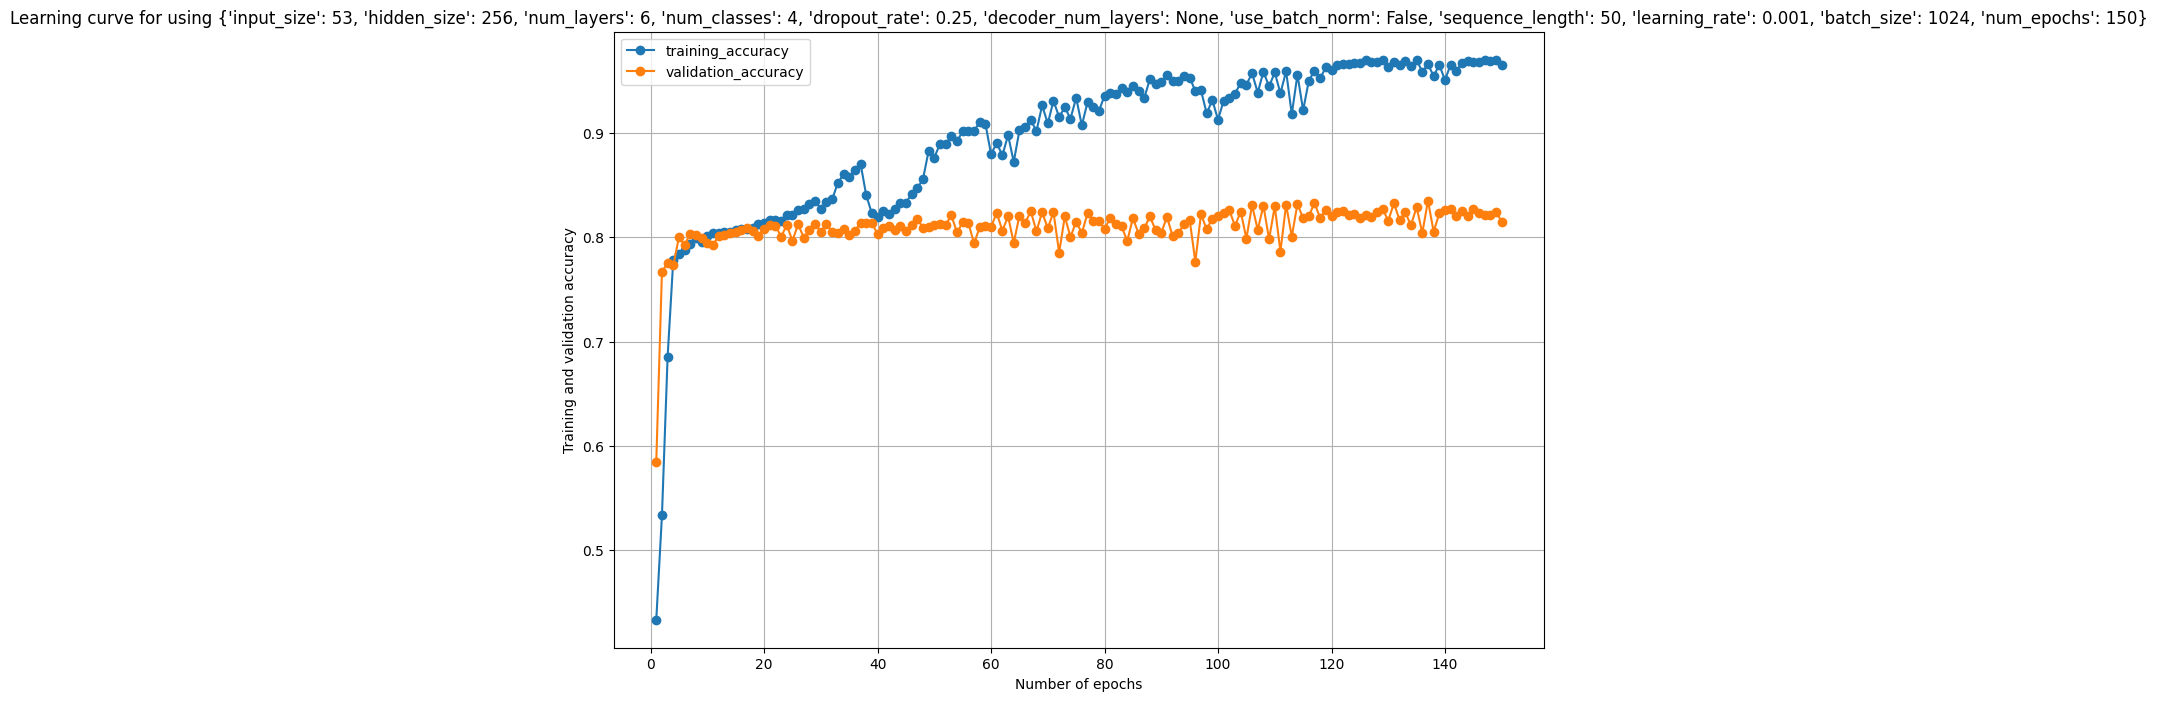

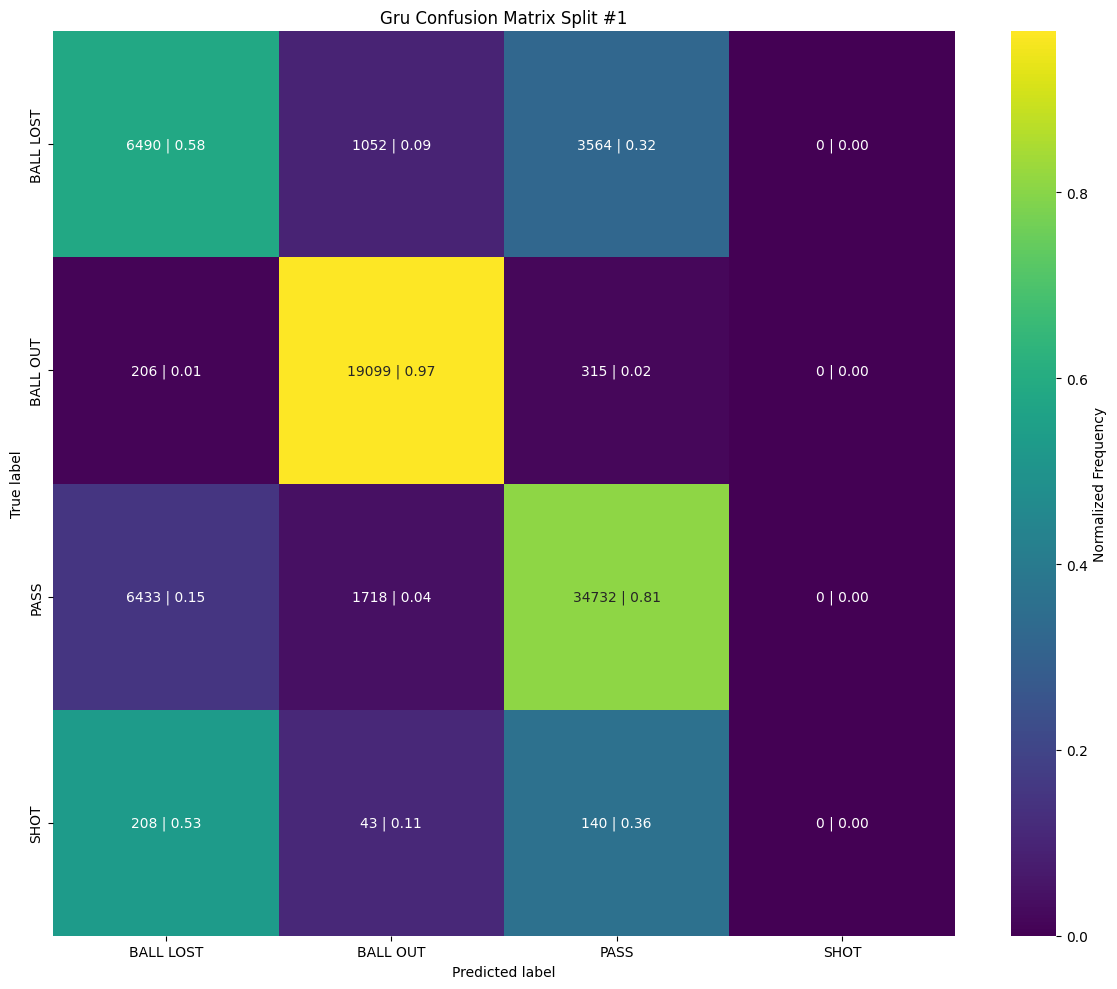

GRU training accuracy: 96.53%
GRU testing accuracy: 81.51%

GRU testing precision: 82.35%
GRU testing recall: 81.51%
GRU testing f1: 81.67%




In [54]:
plot_accuracy_history(acc, title=f"using {str(gru_params)}")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

In [ ]:
a, b, c = test_model(nn_model, validation_loader, nn.CrossEntropyLoss(weight=weights), device)

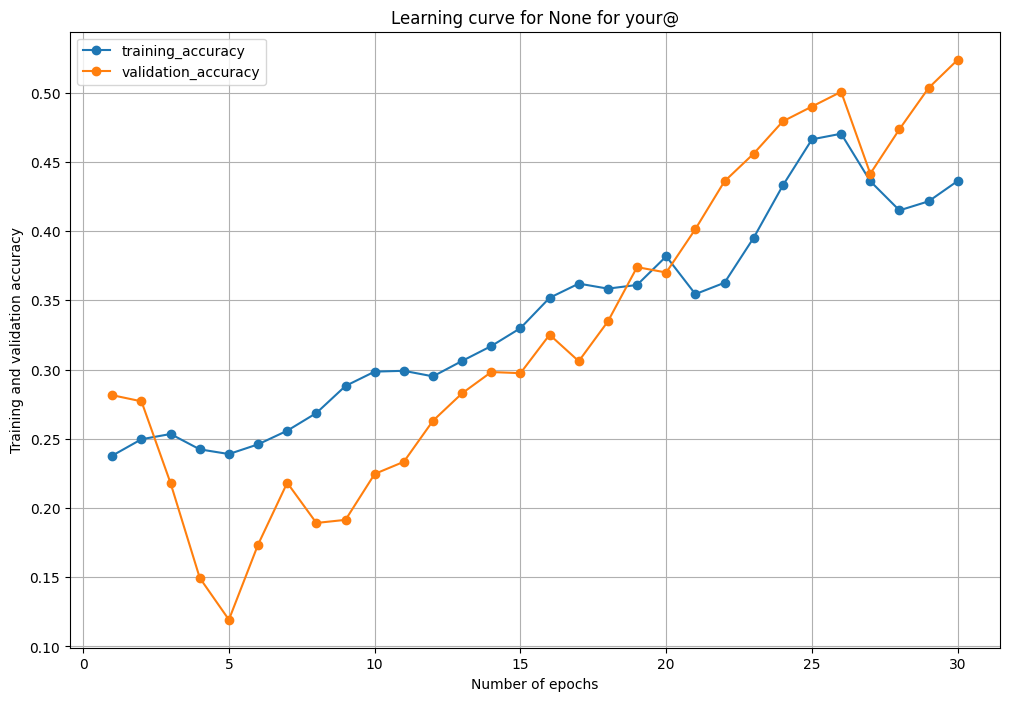

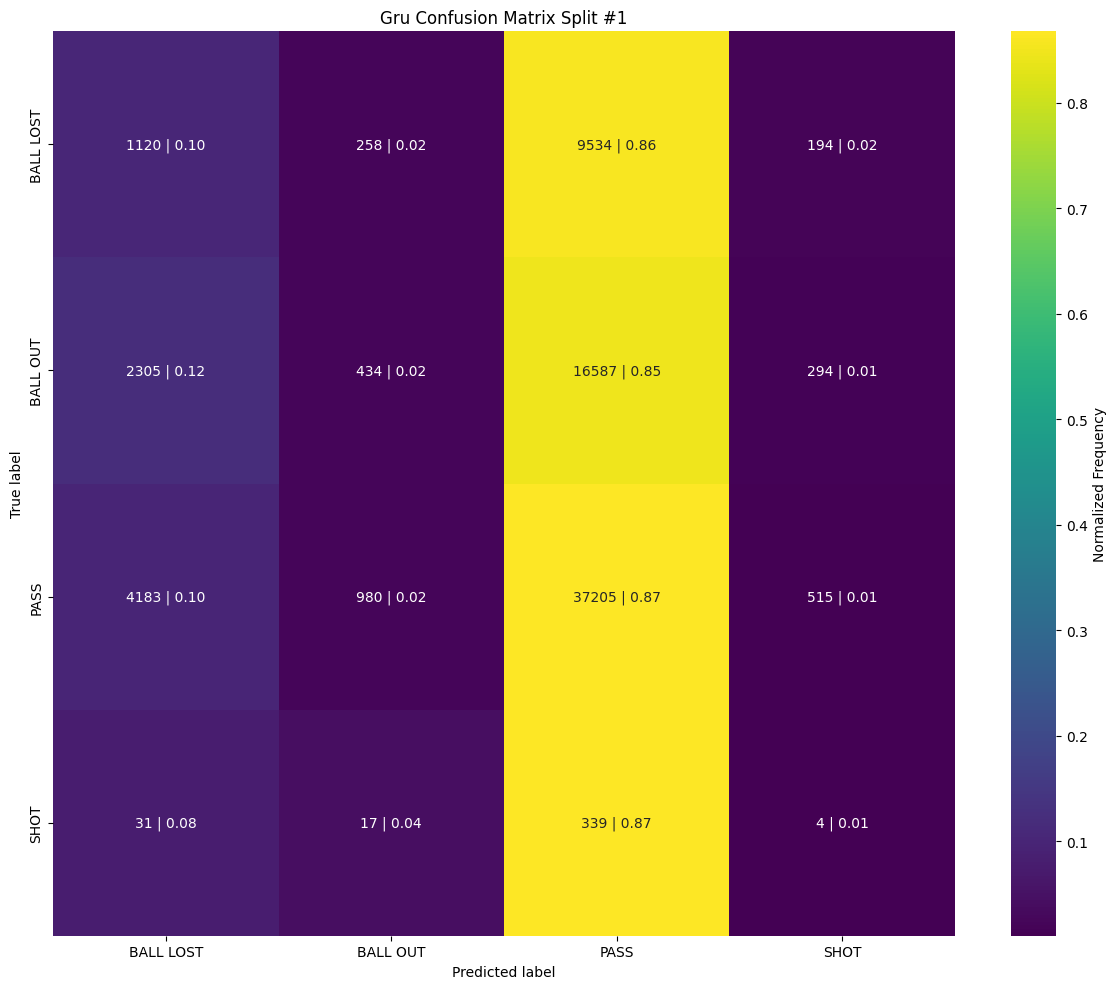

GRU training accuracy: 43.63%
GRU testing accuracy: 52.38%

GRU testing precision: 42.88%
GRU testing recall: 52.38%
GRU testing f1: 43.35%




In [70]:
plot_accuracy_history(acc, title="None for your@")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

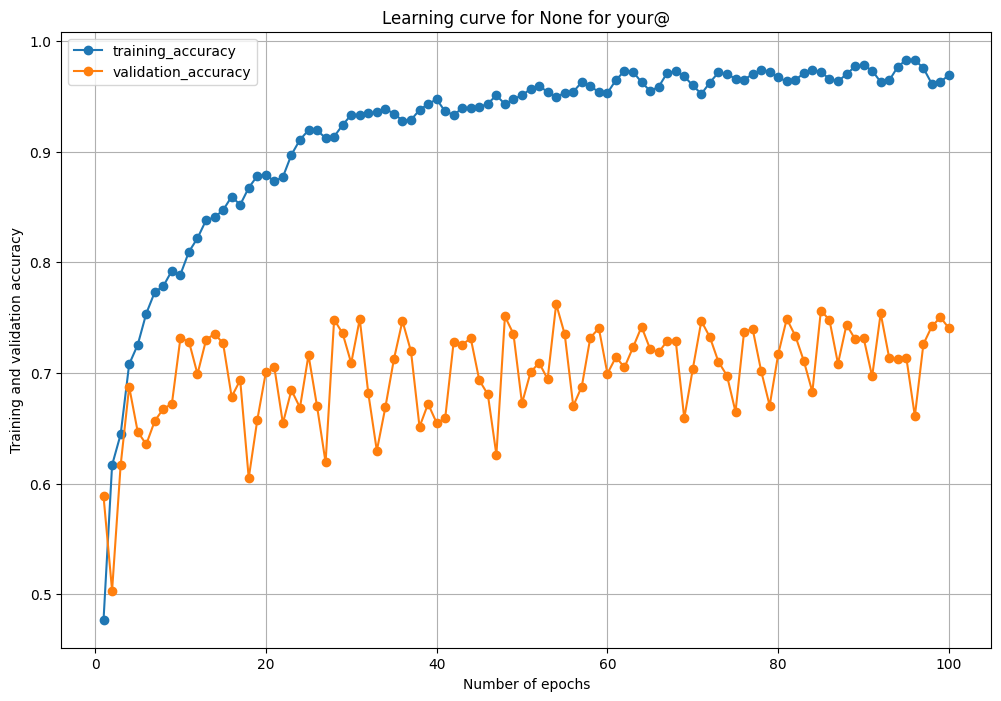

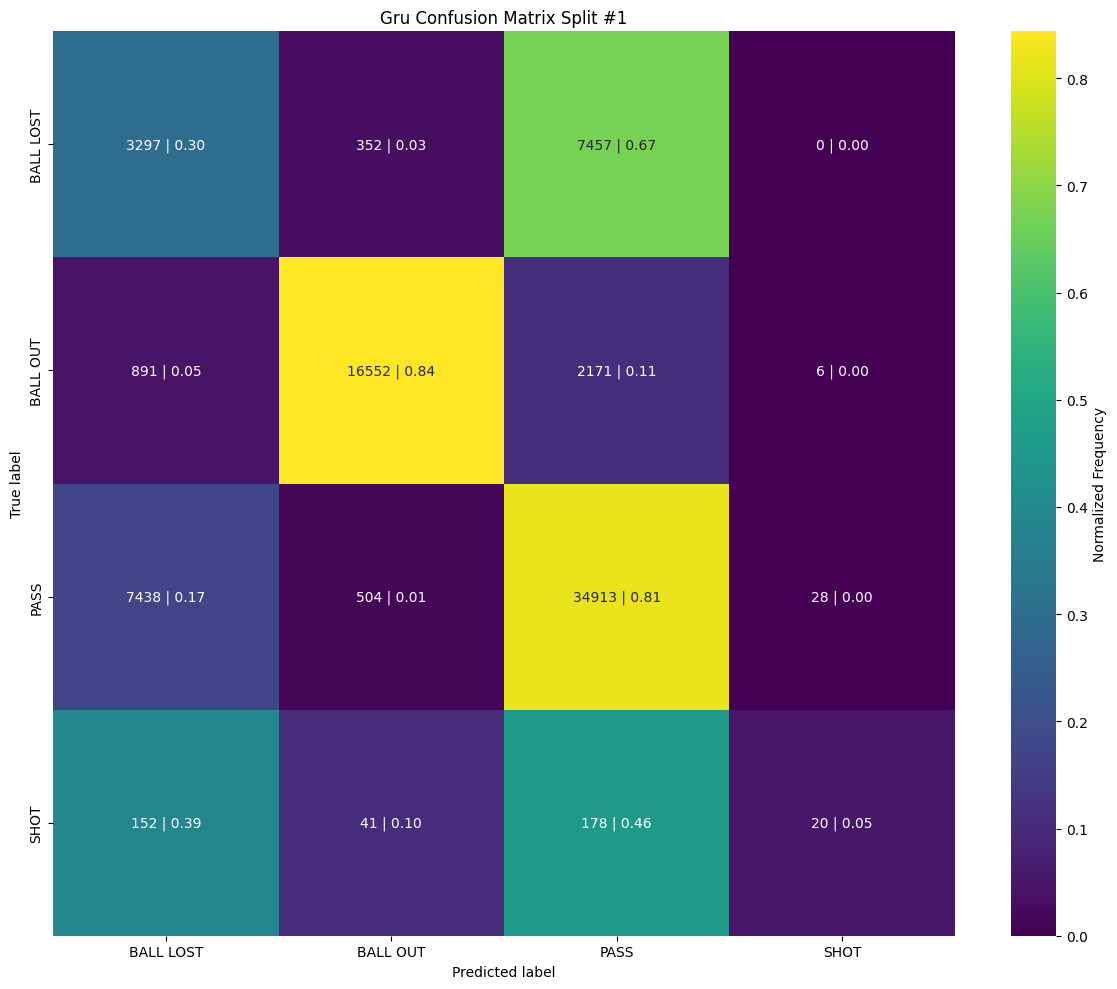

GRU training accuracy: 96.91%
GRU testing accuracy: 74.03%

GRU testing precision: 74.79%
GRU testing recall: 74.03%
GRU testing f1: 74.24%




In [60]:
plot_accuracy_history(acc, title="None for your@")
labels = label_encoder.inverse_transform(np.unique(y_1_encoded))
_ = plot_confusion_matrix(y_train=label_encoder.inverse_transform(y_train), y_train_pred=label_encoder.inverse_transform(y_train_pred), y_test=label_encoder.inverse_transform(y_true), 
                          y_pred=label_encoder.inverse_transform(y_pred), labels=labels, split=0, model_name="GRU")

In [ ]:
25, 36, 48

In [ ]:
Best trial 25: {'batch_size': 512, 'dropout_rate': 0.4086862371340136, 'hidden_size': 256, 'optimizer': 'adam', 'learning_rate': 0.00038819623613215354, 'num_layers': 4, 'sequence_length': 25}
Best accuracy: 0.8583436768774237

In [ ]:
Trial 48 finished with value: 0.8373301638766013 and parameters: {'batch_size': 512, 'dropout_rate': 0.20523009649860546, 'hidden_size': 128, 'optimizer': 'sgd', 'learning_rate': 0.012682942484929386, 'num_layers': 6, 'sequence_length': 25}.

In [60]:
Trial 36 finished with value: 0.8292257189468093 and parameters: {'batch_size': 512, 'dropout_rate': 0.2327694778607767, 'hidden_size': 512, 'optimizer': 'sgd', 'learning_rate': 0.012815264082136263, 'num_layers': 3, 'sequence_length': 25}. Best is trial 25 with value: 0.8583436768774237.

SyntaxError: invalid syntax (4225598917.py, line 1)

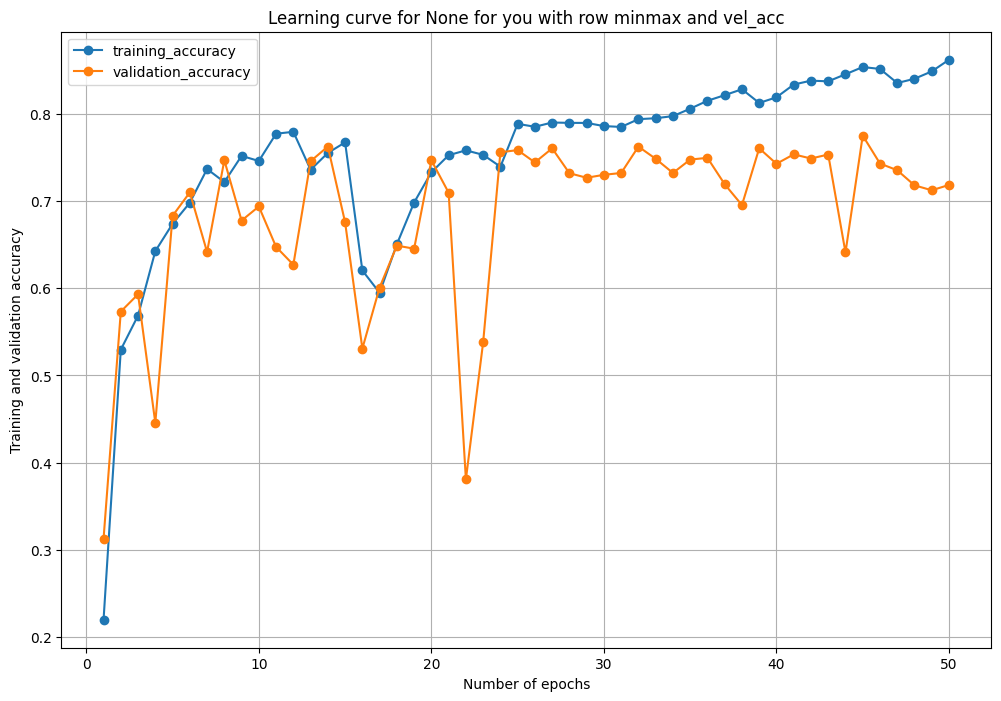

In [68]:
plot_accuracy_history(acc, title="None for you with row minmax and vel_acc")

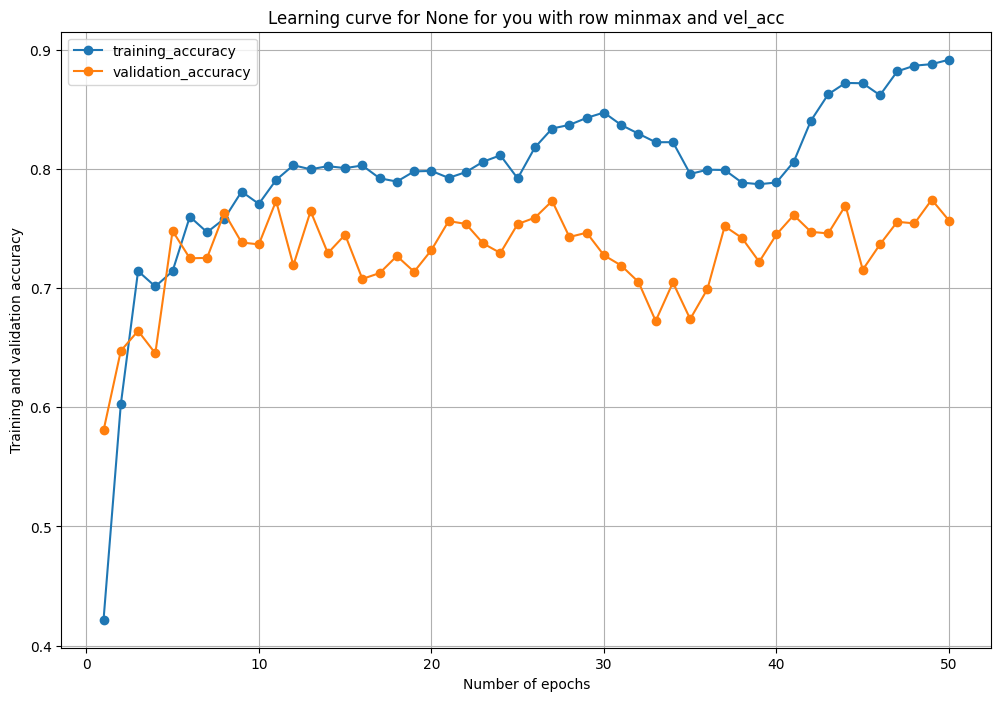

In [56]:
plot_accuracy_history(acc, title="None for you with row minmax and vel_acc")

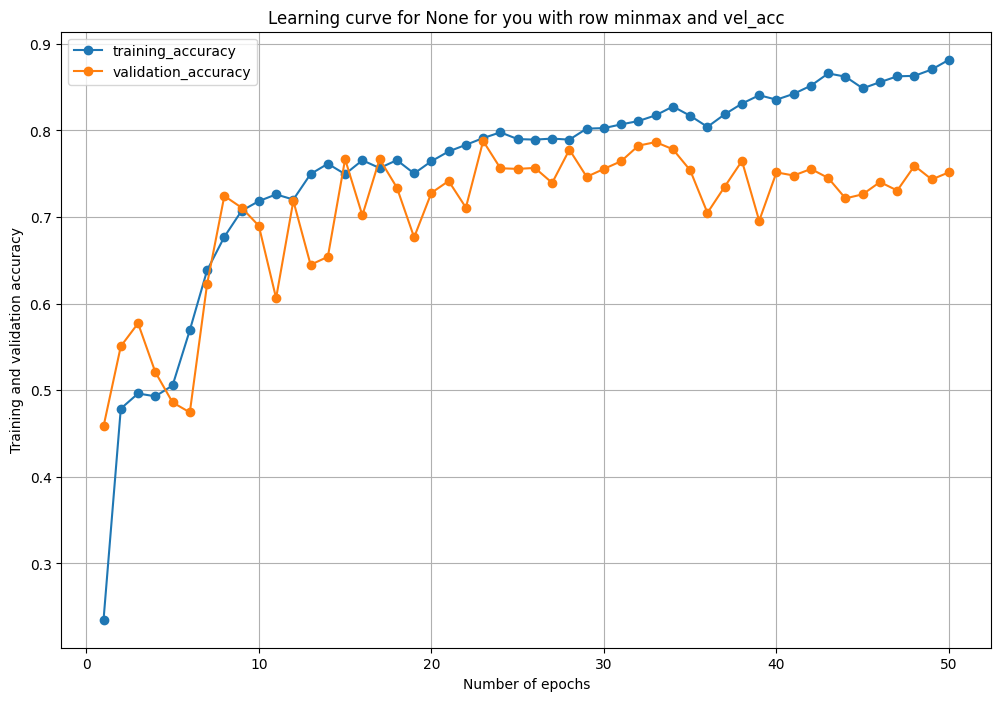

In [88]:
plot_accuracy_history(acc, title="None for you with row minmax and vel_acc")

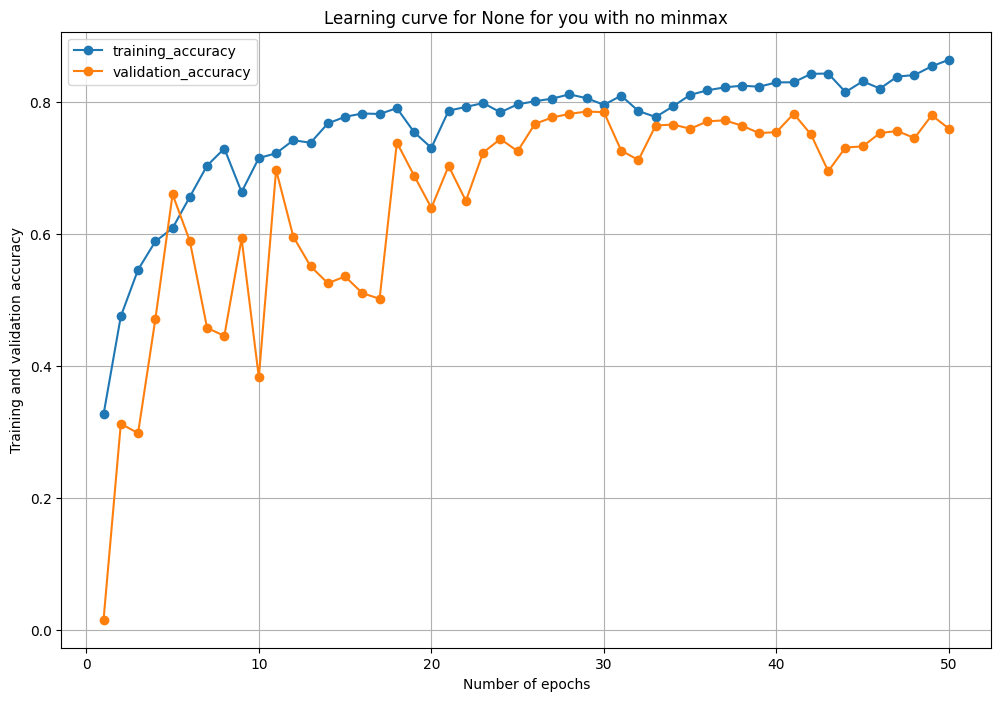

In [89]:
plot_accuracy_history(acc, title="None for you with no minmax")

In [ ]:
plot_accuracy(acc, title="Trial 48 with 50 SL")

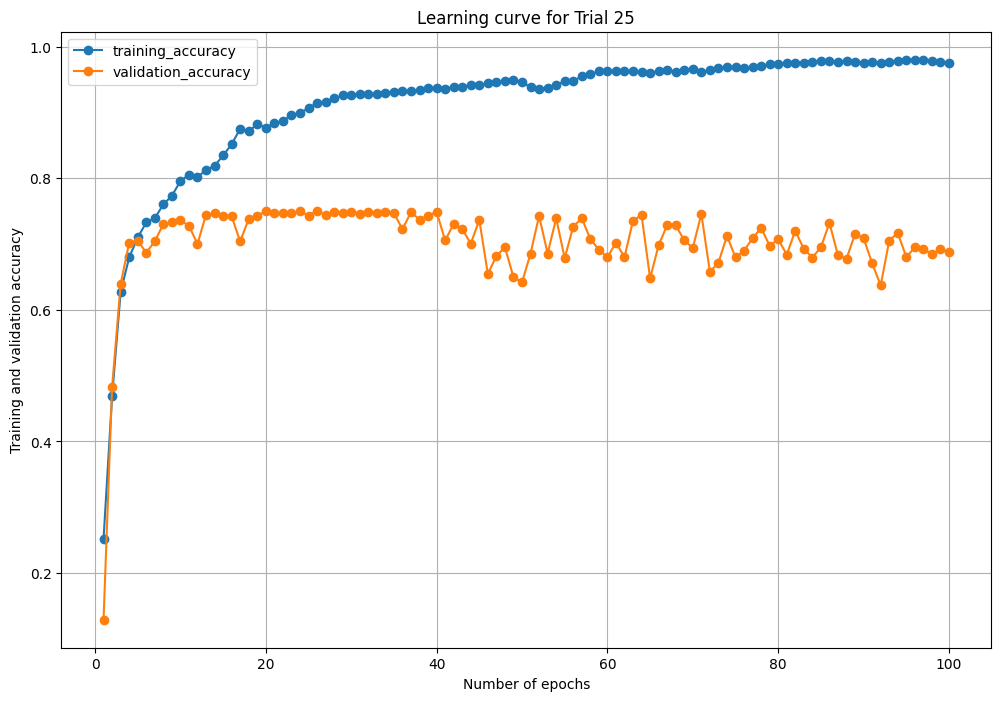

In [75]:
plot_accuracy(acc, title="Trial 25")